# Predicting Daily EMS Calls

## Goals
1. Build a 1-day-horizon prediction model, which can be used 


### Trends of daily calls
Figure 1 below shows the monthly EMS calls received from 01/2022-09/2023. We can see a long term trend over these years, which EMS forecasting literature tends to attribute to demographic factors such as population growth and aging [[1](#references)]. We can also see a steep dropoff in monthly calls when Covid lockdowns in the US were initiated and in the proceeding months when [many SF residents moved away](https://www.kqed.org/news/11909141/sf-lost-more-than-116000-residents-during-pandemics-first-year).

In [1]:
from raw_data_analysis.utils import get_daily_calls_global, train_test_split
import warnings
warnings.filterwarnings('ignore')
daily_calls = get_daily_calls_global(weather=True, total=True, events=True, root_path='raw_data_analysis')
train, valid, _ = train_test_split(daily_calls.iloc[439:], n_valid=365)

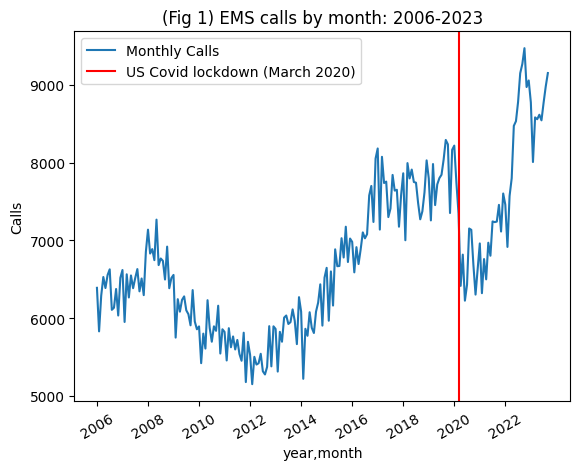

In [2]:
import matplotlib.pyplot as plt
train.iloc[:-4].groupby(['year', 'month']).calls.sum().plot(
  ylabel='Calls', title='(Fig 1) EMS calls by month: 2006-2023',
  label='Monthly Calls')
plt.axvline(x=170, color='red', label='US Covid lockdown (March 2020)')
plt.xticks([i*24 for i in range(9)], labels=[str(y) for y in range(2006, 2023, 2)],
           rotation=30)
plt.legend();

Figure 2 and 3 show quantiles of calls by day of week and by month, respectively. While the spread in calls by day of week and by month don't vary much, we can see a peak in calls on fridays, which may reflect the general activity of the city on fridays at the end of the week. There may also be some weekly/yearly trends which we'll explore later.

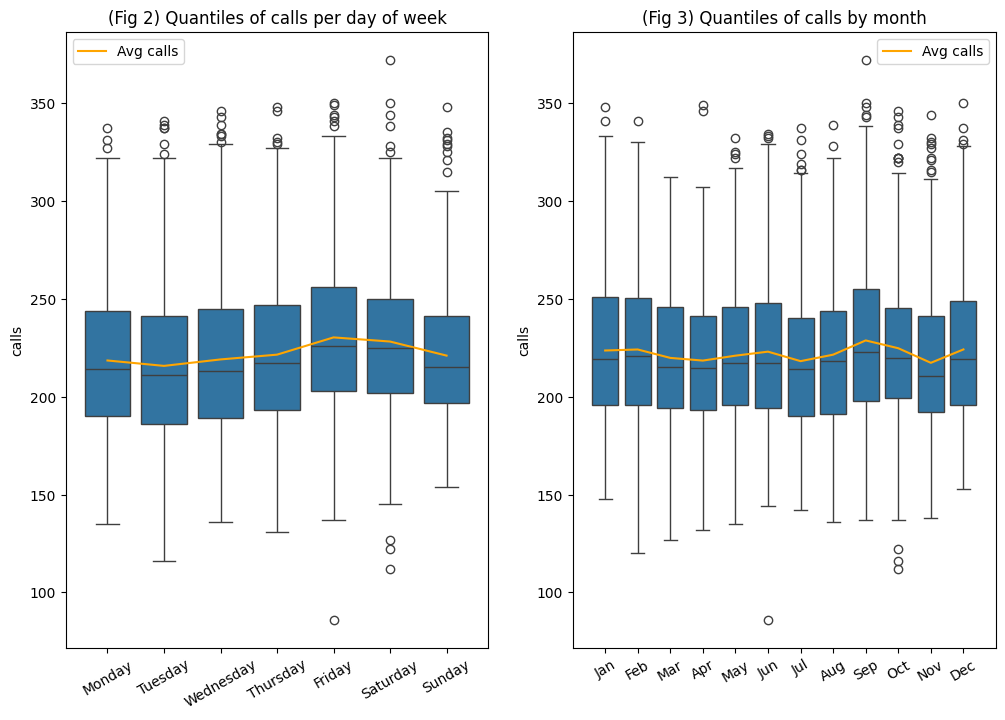

In [3]:
import seaborn as sns
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
ax1, ax2 = axs[0], axs[1]
sns.boxplot(train, x='dayofweek', y='calls', ax=ax1)
sns.lineplot(train.groupby('dayofweek').calls.mean(), color='orange', label='Avg calls', ax=ax1)
ax1.set_xlabel('')
ax1.set_title('(Fig 2) Quantiles of calls per day of week');
ax1.set_xticks(list(range(7)),
           labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
           rotation=30);

sns.boxplot(train, x='month', y='calls', ax=ax2)
sns.lineplot(train.groupby('month').calls.mean().values, color='orange', label='Avg calls', ax=ax2)
ax2.set_xlabel('')
ax2.set_title('(Fig 3) Quantiles of calls by month');
ax2.set_xticks(list(range(12)),
           labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
           rotation=30);

### Baseline model: 1-day SARIMA forecasting
ARMA models are classic statistical models that take advantage of autocorrelation in time series to make forecasts. Specifically, they model each value in the time series as a linear combination of previous values (auto regressive (AR) terms) and residuals (moving average (MA) terms). However, they require that the time series be stationary, meaning that its mean and variance do not change over time. Clearly from figure 1, the mean of our time series (which will be daily EMS call demand) does change over time, and from figure 2, there's reason to believe there is some weekly seasonality [[1-3]](#references). SARIMA models, which are just an extension of ARMA models, help with these 2 issues.

In order to estimate these models, we need to explore several things:
1. What order of differencing will lead to a constant-mean time series.
2. How many lag and residuals terms to use in our SARIMA model.
3. How many seasonal lag and residual terms to use in our SARIMA model.

To explore the effect of differencing on stationarity, we'll use the Augmented Dickey–Fuller test, whose null hypothesis is that the time series has a unit root (and is not stationary) and has the alternative hypothesis that the time series has no unit root (and is stationary).

ADF test with 1st order differencing. p-value: 0.0


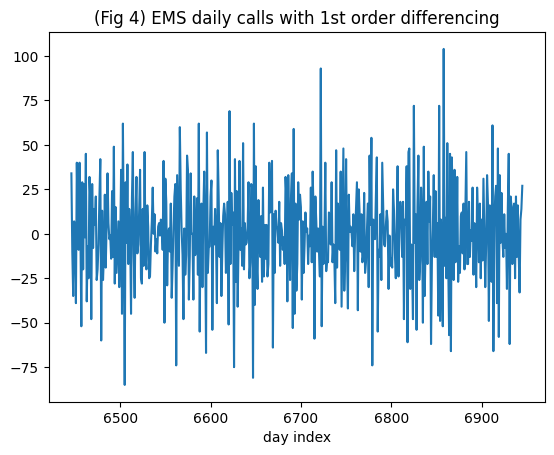

In [103]:
from statsmodels.tsa.stattools import adfuller
train.calls.diff()[-500:].plot(title='(Fig 4) EMS daily calls with 1st order differencing', xlabel='day index')
pval = adfuller(train.calls.diff()[1:])[1]
print(f'ADF test with 1st order differencing. p-value: {pval}')

It looks like 1st order differencing makes our time series stationary. Next, let's explore the autocorrelation (ACF) and partial autocorrelation (PACF) plots of our differenced time series. The ACF plot represents the correlation of the time series with itself at different lags (e.g. $ACF(i)=\rho_{X_t, X_{t-i}})$), and the PACF is the same except it removes the effects of previous lags. In other words, at index $i$, the PACF plot is the correlation between $X_t$ and $X_{t-i}$ with the linear dependence of $X_t$ on $X_{t-1}, ..., X_{t-i+1}$ removed. Generally, the ACF and PACF plots gives an idea of the amount of MA and AR terms to use, respectively.

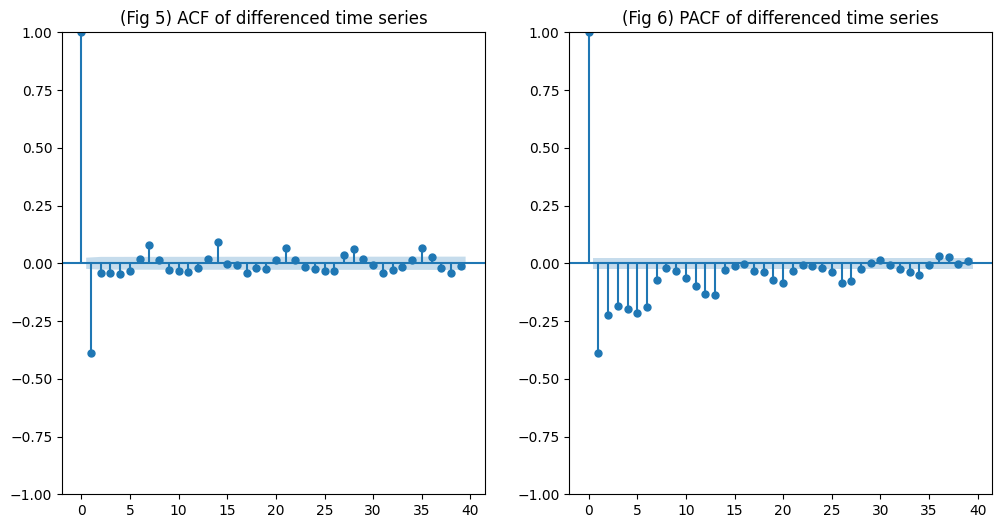

In [108]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
diffed = train.calls.diff()[1:]
fig, axs = plt.subplots(1, 2, figsize=(12,6))
plot_acf(diffed, ax=axs[0], title='(Fig 5) ACF of differenced time series')
plot_pacf(diffed, ax=axs[1], title='(Fig 6) PACF of differenced time series');


Both figure 5 and 6 show some periodicity of 7, which support our earlier hypothesis that there is weekly seasonality in EMS call demand. The ACF shows we should have at least 1 MA and seasonal MA term, and the PACF shows we may want more than 1 AR and seasonal AR terms. 

In this setting, it's common practice to try out different SARIMA parameters and use the AIC criterion to select the best model, which helps balance model complexity and likelihood. Let's do that now:

In [ ]:
import itertools
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
def auto_sarima():
  # Trying # terms: AR=1-3, MA=1-2
  p, d, q = range(1, 4), [1], range(1, 3)
  pdq = list(itertools.product(p, d, q))

  # Trying # seasonal terms: AR=1-3, MA=1-2
  P, D, Q = range(1, 4), [1], range(1, 3)
  seasonal_pdq = [(x[0], x[1], x[2], 7) for x in list(itertools.product(P, D, Q))]

  search_results = []
  for param in pdq:
      for param_seasonal in seasonal_pdq:
            print(f'trying {param}, {param_seasonal}')
            # Only using the last 1200 training points (roughly the data points)
            # after the covid lockdown) to make training time feasible.
            mod = sm.tsa.statespace.SARIMAX(train.calls[-1200:],
                                            order=param,
                                            seasonal_order=param_seasonal)
            results = mod.fit(disp=0)
            search_results.append(('SARIMA{}x{}'.format(param, param_seasonal), results.aic))
  return search_results
sarima_param_results = auto_sarima()

In [125]:
# Model parameters with the lowest AIC
sorted(sarima_param_results, key=lambda x: x[1])[0]

('ARIMA(1, 1, 1)x(1, 1, 1, 7)7', np.float64(10752.184277622535))

Now, let's train our best SARIMA model based on the parameters above that minimized AIC on the full training data and plot some model diagnostics, which show that our training residuals look close to normal (except at the tails) and have no autocorrelation.

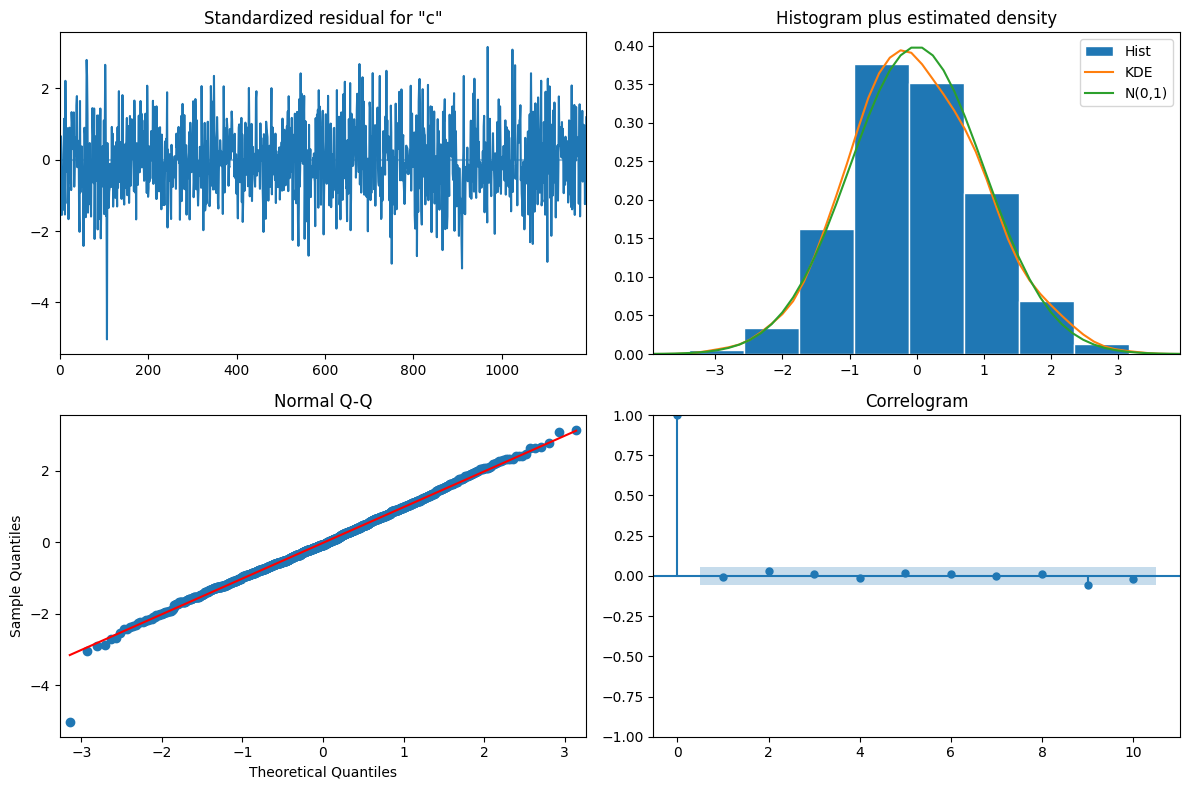

In [173]:
import statsmodels.api as sm

arima_mod = sm.tsa.statespace.SARIMAX(train.calls[-1200:],
                                      order=(1, 1, 1),
                                      seasonal_order=(1, 1, 1, 7))
arima_mod_res = arima_mod.fit(disp=0)
arima_mod_res.plot_diagnostics();
plt.tight_layout()

In [10]:
from sklearn import metrics
from dataclasses import dataclass

@dataclass
class PlotArgs:
   fig_i: int
   model: str
def validation_metrics(y_true, y_pred, plot_args):
  assert len(y_true) == len(y_pred)
  yidx = list(range(len(y_true)))

  print(f'RMSE: {metrics.root_mean_squared_error(y_true, y_pred):.4}')
  print(f'MAPE: {metrics.mean_absolute_percentage_error(y_true, y_pred):.4f}')
  print(f'MAE: {metrics.mean_absolute_error(y_true, y_pred):.4f}')
  plt.plot(yidx, y_true, label='True')
  plt.plot(yidx, y_pred, label='Predicted')
  plt.legend()

  validation_months = pd.date_range(start="2023-11-01", end="2024-10-01", freq="MS")
  month_tick_pos = valid[valid.received_date.isin(validation_months)].index-valid.index[0]
  plt.xticks(
     ticks=list(month_tick_pos),
     labels=['Nov 01, 23', 'Dec 01', 'Jan 01, 24', 'Feb 01', 'Mar 01', 'Apr 01',
             'May 01', 'Jun 01', 'Jul 01', 'Aug 01', 'Sep 01', 'Oct 01'],
     rotation=40
     )
  plt.title(f'(Fig {plot_args.fig_i}) {plot_args.model}: validation performance')

RMSE: 24.06
MAPE: 0.0725
MAE: 19.3793


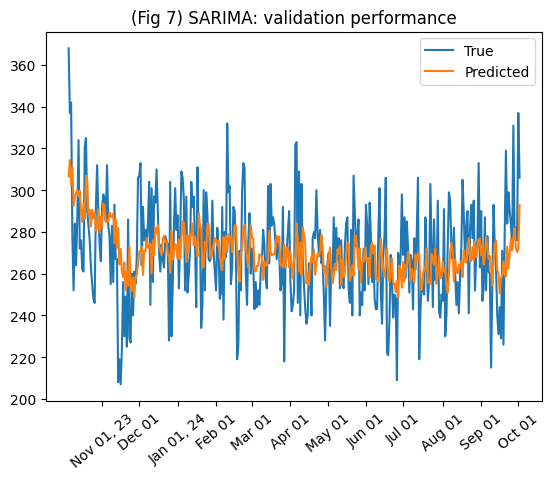

In [171]:


def eval_sarima(model_res, y_true, plot_args):
  # Perform the rolling forecast
  preds = []
  for step in range(len(y_true)):
      # Get 1-step-ahead forecast from the end of the current predictions
      forecast_val = model_res.get_forecast(steps=1).predicted_mean.iloc[0]
      preds.append(forecast_val)

      # Update the model with the new observation
      model_res = model_res.append(endog=[y_true.iloc[step]])

  validation_metrics(y_true, preds, plot_args)

eval_sarima(arima_mod_res, valid.calls, PlotArgs(7, 'SARIMA'))
  


In figure 7, we can see how the SARIMA preditions follow the trend of EMS demand well but don't capture the variation in EMS demand well. Let's see if we can do better by modeling more temporal patterns in our data with other kinds of ML models: linear regression (LR), support vector regression (SVR), and gradient boosting trees (XGBoost).

In the following, we will continue to use lagged features (lags 1-7, 14, and 21) based on our "auto sarima" procedure and the PACF plot (figure 6) from before.

### Representing time steps as categories
In our dataset, we have year, month, day of week, and week of the year as different discrete covariates, and we could treat these as categorical variables using one-hot encoding. This would ignore any relationships in the ordering of these values.

Let's first try linear models with L1 regularization since we'll be adding many more covariates through one hot encoding and will want to filter out less informative features.

In [8]:
def eval_lasso(model, X_valid, y_valid, plot_args, transformer):
    reg = model.named_steps['lassocv']
    feats_coefs = pd.DataFrame({
        'feature': transformer.get_feature_names_out(),
        'coefficient': reg.coef_})
    print('Top 15 features:')
    print(feats_coefs.sort_values('coefficient', key=abs, ascending=False).head(15))
    print(f'Used {(reg.coef_ != 0).sum()}/{len(reg.coef_)} features')
    validation_metrics(y_valid, model.predict(X_valid), plot_args)

Top 15 features:
                 feature  coefficient
0           scaler__lag1    78.040386
7          scaler__lag14    41.353764
1           scaler__lag2    31.512751
8          scaler__lag21    29.457583
6           scaler__lag7    27.718245
5           scaler__lag6    22.107054
2           scaler__lag3    14.719367
4           scaler__lag5    10.674635
3           scaler__lag4     8.889558
36     encoder__week_8.0    -7.947510
77    encoder__week_49.0     6.773217
63    encoder__week_35.0     6.285522
14  encoder__dayofweek_4     6.151073
9           scaler__year     5.718847
75    encoder__week_47.0    -4.777309
Used 72/82 features
RMSE: 23.65
MAPE: 0.0704
MAE: 18.8395
Used 46 features to represent week of year
Used 10 features to represent month
Used 6 features to represent day of week


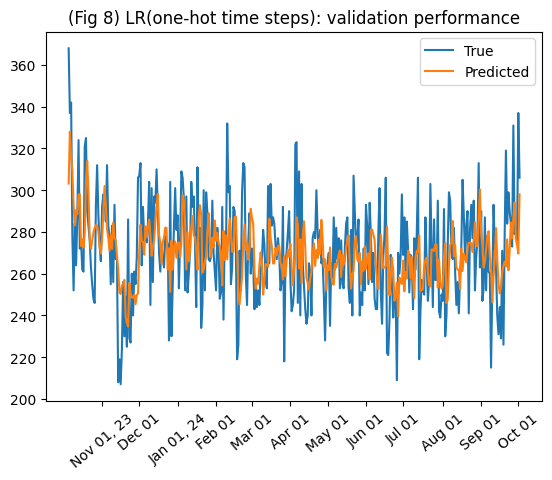

In [11]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
cat_cols = ['dayofweek', 'month', 'week']

feats = num_cols + cat_cols
X_train, y_train = train[feats], train.calls
X_valid, y_valid = valid[feats], valid.calls

# This will create 5 splits in our training data during cross fold validation
# that we'll use for the rest of this analysis.
# |-------------------original training data------------------------|
# |--------------train1--------------|-val1-|
# |--------------train2---------------------|-val2-|
# |--------------train3----------------------------|-val3-|
# |--------------train4-----------------------------------|val4|
# |--------------train5----------------------------------------|val5|
ts_cv = TimeSeriesSplit(
    n_splits=5,
    test_size=365,
)

transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ('encoder', OneHotEncoder(), cat_cols)
    ], remainder='passthrough')

model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train, y_train)
eval_lasso(model, X_valid, y_valid, PlotArgs(8, 'LR(one-hot time steps)'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]
print(f'Used {len([feat for feat in used_feats if "encoder__week" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "encoder__month" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "encoder__dayofweek" in feat])} features to represent day of week')

With one-hot encoded time steps, we've reduced RMSE by 1.7%, MAE by 2.7%, and MAPE by 0.2 points, and we can see that this model captures the EMS call demand variability better. 

We can try an alternate encoding of these temporal features using splines in order to capture the possible seasonal effects by week, month, and day of week that are shown in the figure below:

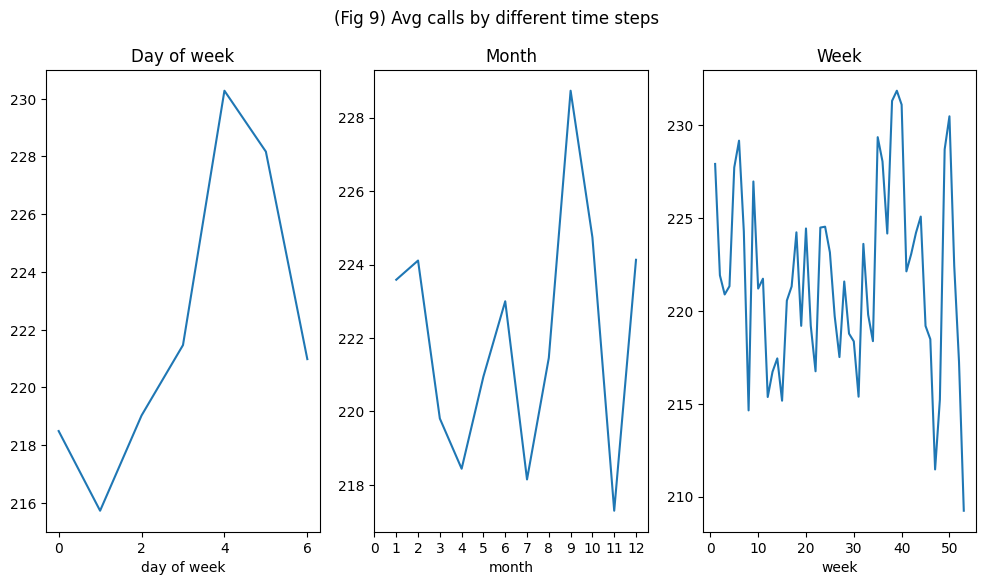

In [191]:
fig, axs = plt.subplots(1,3, figsize=(12,6))
train.groupby('dayofweek').calls.mean().plot(ax=axs[0], title='Day of week', xlabel='day of week');
train.groupby('month').calls.mean().plot(ax=axs[1], title='Month', xticks=list(range(13)));
train.groupby('week').calls.mean().plot(ax=axs[2], title='Week');
fig.suptitle('(Fig 9) Avg calls by different time steps');


Using splines, we can model periodic, polynomial-like relationships between these time steps and EMS call demand. For instance, if we use 3 periodic splines, figure 10 shows the splines that would be used to represent the day of week feature, and the linear model would try to find the best linear combination of these 3 splines to represent the relationship between day of week and EMS call demand.

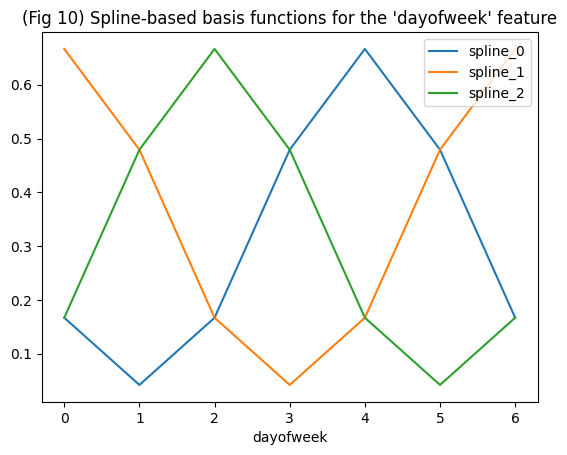

In [12]:
from sklearn.preprocessing import SplineTransformer
import numpy as np
def periodic_spline_transformer(n_splines, degree=3):
    return SplineTransformer(
        degree=degree,
        n_knots=n_splines + 1,
        extrapolation="periodic",
        include_bias=True,
    )

dayofweek = pd.DataFrame(
    np.linspace(0, 6, 7).reshape(-1, 1),
    columns=["dayofweek"],
)
splines = periodic_spline_transformer(3).fit_transform(dayofweek)
splines_df = pd.DataFrame(
    splines,
    columns=[f"spline_{i}" for i in range(splines.shape[1])],
)
pd.concat([dayofweek, splines_df], axis="columns").plot(x="dayofweek")
plt.title("(Fig 10) Spline-based basis functions for the 'dayofweek' feature");

Below is the linear model for using 12, 7, and 52 splines for the month, day of week, and week features, respectively.

Top 15 features:
                             feature  coefficient
0                       scaler__lag1    78.743685
7                      scaler__lag14    41.634309
1                       scaler__lag2    31.733753
8                      scaler__lag21    29.476716
6                       scaler__lag7    27.133064
5                       scaler__lag6    21.621154
2                       scaler__lag3    14.677875
37            cyclic_week__week_sp_8   -11.521354
4                       scaler__lag5    10.307595
64           cyclic_week__week_sp_35    10.225098
28  cyclic_dayofweek__dayofweek_sp_6     9.854174
78           cyclic_week__week_sp_49     9.160996
3                       scaler__lag4     8.671953
76           cyclic_week__week_sp_47    -7.367690
38            cyclic_week__week_sp_9     7.070702
Used 58/81 features
RMSE: 23.62
MAPE: 0.0703
MAE: 18.8410
Used 42 features to represent week of year
Used 6 features to represent month
Used 4 features to represent day of week


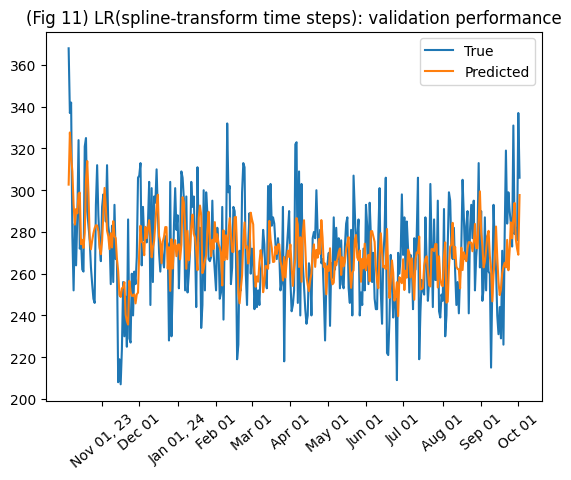

In [14]:
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train, y_train)
eval_lasso(model, X_valid, y_valid, PlotArgs(11, 'LR(spline-transform time steps)'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]
print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')

The model performance is about the same, but this model uses 58 features instead of 72 features from the model with one-hot encoded categories, which shows that splines can represent the relationship between these time steps and EMS call demand more efficiently than one-hot encoding.

Next, let's see how SVR with RBF kernel and XGBoost do on our features so far, given that these are 2 ways to model non-linear relationships.

(Just show results)

RMSE: 23.68
MAPE: 0.0703
MAE: 18.9925


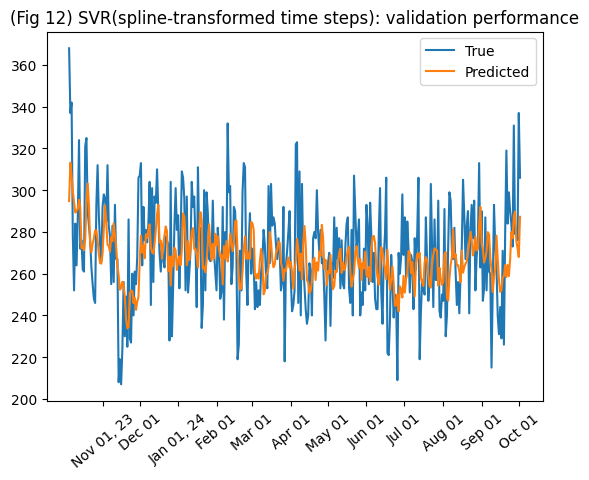

In [238]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')

model = make_pipeline(transformer,
                    GridSearchCV(SVR(),
                                 # These parameters are the ones chosen after
                                 # much more turning previously
                                 param_grid={
                                     'C': [100, 200, 300],
                                     'epsilon': [1e-05, 1e-04],
                                     'gamma': [0.001]
                                 },
                                 scoring='neg_root_mean_squared_error',
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train, y_train)
validation_metrics(y_valid, model.predict(X_valid), PlotArgs(12, 'SVR(spline-transformed time steps)'))

RMSE: 23.71
MAPE: 0.0703
MAE: 18.9857


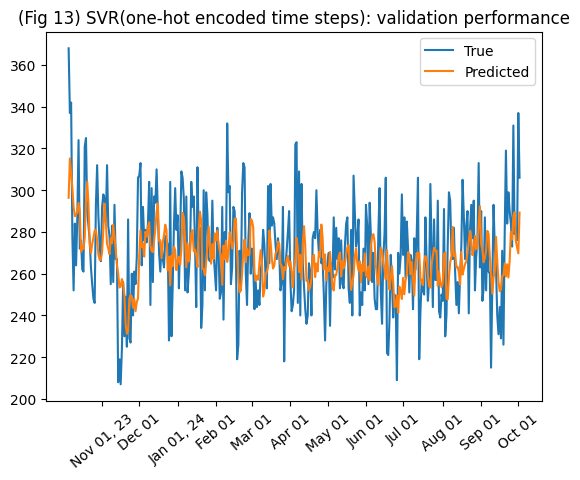

In [239]:
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
cat_cols = ['dayofweek', 'month', 'week']
transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ('encoder', OneHotEncoder(), cat_cols)
    ], remainder='passthrough')
model = make_pipeline(transformer,
                    GridSearchCV(SVR(),
                                 # These parameters are the ones chosen after
                                 # much more turning previously
                                 param_grid={
                                     'C': [100, 200, 300],
                                     'epsilon': [1e-05, 1e-04],
                                     'gamma': [0.001]
                                 },
                                 scoring='neg_root_mean_squared_error',
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train, y_train)
validation_metrics(y_valid, model.predict(X_valid), PlotArgs(13, 'SVR(one-hot encoded time steps)'))

RMSE: 23.78
MAPE: 0.0724
MAE: 19.2062


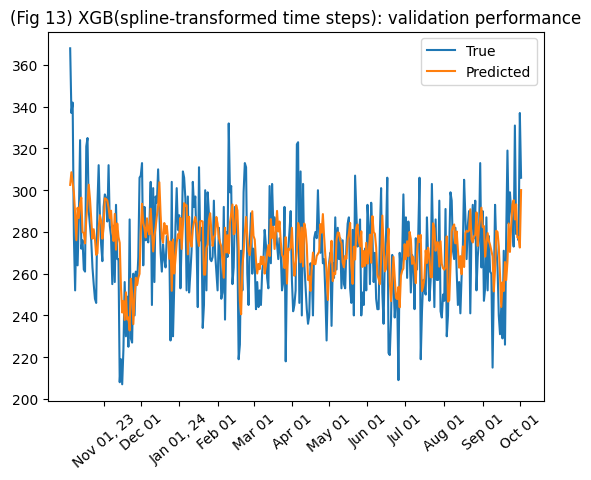

In [241]:
from xgboost import XGBRegressor

num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')

model = make_pipeline(transformer, 
                    GridSearchCV(XGBRegressor(learning_rate =0.1, n_estimators=140, max_depth=5,
                                               min_child_weight=1, gamma=0, subsample=0.8, colsample_bytree=0.8,
                                               scale_pos_weight=1, seed=27),
                                 param_grid={
                                     'n_estimators':[100, 140, 200, 250],
                                     'learning_rate': [0.05, 0.1],
                                     'gamma': [0, 0.3, 0.6, 1, 1.5],
                                     'max_depth': [3, 5],
                                     'min_child_weight': [1, 3],
                                 },
                                 scoring='neg_root_mean_squared_error',
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train, y_train)
validation_metrics(y_valid, model.predict(X_valid), PlotArgs(13, 'XGB(spline-transformed time steps)'))

RMSE: 24.35
MAPE: 0.0739
MAE: 19.6851


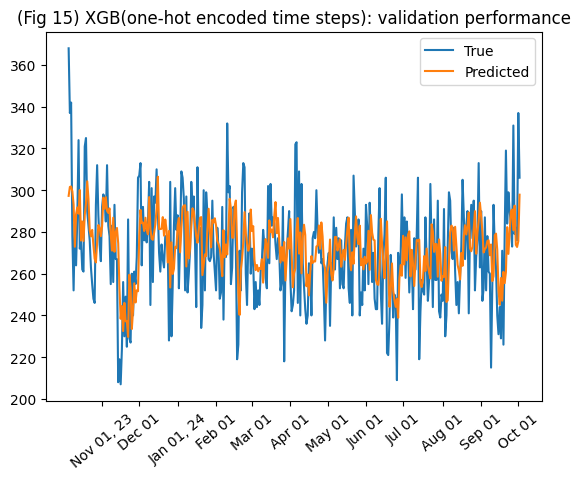

In [246]:
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year']
cat_cols = ['dayofweek', 'month', 'week']
transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ('encoder', OneHotEncoder(), cat_cols)
    ], remainder='passthrough')

model = make_pipeline(transformer, 
                    GridSearchCV(XGBRegressor(learning_rate =0.1, n_estimators=140, max_depth=5,
                                               min_child_weight=1, gamma=0, subsample=0.8, colsample_bytree=0.8,
                                               scale_pos_weight=1, seed=27),
                                 param_grid={
                                     'n_estimators':[60, 100, 140],
                                     'learning_rate': [0.05, 0.1],
                                     'gamma': [0, 0.3],
                                     'max_depth': [3, 5],
                                     'min_child_weight': [1, 3],
                                 },
                                 scoring='neg_root_mean_squared_error',
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train, y_train)
validation_metrics(y_valid, model.predict(X_valid), PlotArgs(15, 'XGB(one-hot encoded time steps)'))

In [308]:
models = [
  'LR Lasso',
  'LR Lasso',
  'SVR',
  'SVR',
  'XGBoost',
  'XGBoost'
]
features = [
  'one-hot encoding',
  'spline transformations',
  'one-hot encoding',
  'spline transformations',
  'one-hot encoding',
  'spline transformations'
]
RMSE = [23.65, 23.62, 23.71, 23.68, 24.35, 23.78]
MAE = [18.84, 18.84, 18.98, 18.99, 19.68, 19.21]
MAPE = [.070, .070, .070, .070, .074, .072]
pd.DataFrame({
  'model type': models,
  'temporal feature type': features,
  'RMSE': RMSE, 'MAE': MAE, 'MAPE': MAPE
})

,model type,temporal feature type,RMSE,MAE,MAPE
0,LR Lasso,one-hot encoding,23.65,18.84,0.070
1,LR Lasso,spline transformations,23.62,18.84,0.070
2,SVR,one-hot encoding,23.71,18.98,0.070
3,SVR,spline transformations,23.68,18.99,0.070
4,XGBoost,one-hot encoding,24.35,19.68,0.074
5,XGBoost,spline transformations,23.78,19.21,0.072


The LR Lasso model performs the best overall, although it's unclear how meaningfully better it is than the SVR and XGBoost models.

## Adding weather features

[[4]](#references) showed that adding average temperature as a feature improved forecasts of daily ambulance calls, so we'll try that here. Our weather data is pulled from [Visual Crossing](https://www.visualcrossing.com/), which many businesses use for historical weather data and current forecasts. Ideally, we would use historical forecasts as features since if we deployed our model into production, we would have to use weather forecasts to do 1-day predictions of EMS calls, but I couldn't easily find a data source for that.

Below, is a correlation heat map of each weather variable with EMS calls:

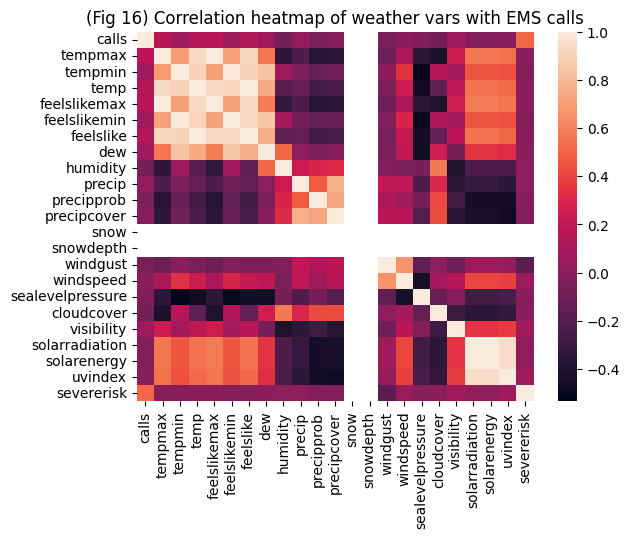

In [4]:
import pandas as pd
import seaborn as sns
weather = pd.concat([
  pd.read_csv("raw_data_analysis/sf-daily-20140101-20241021.csv"),
  pd.read_csv("raw_data_analysis/sf-daily-20060101-20131231.csv")])
weather.datetime = pd.to_datetime(weather.datetime)
weather.severerisk = weather.severerisk.fillna(0)
train_weather = pd.merge(train.drop(['tempmax', 'cloudcover'], axis=1), weather, left_on='received_date', right_on='datetime', how='left')

num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'snow', 'snowdepth', 'windgust',
    'windspeed', 'sealevelpressure', 'cloudcover', 'visibility',
    'solarradiation', 'solarenergy', 'uvindex', 'severerisk'
]
corr = train_weather[['calls'] + num_weather_feats].corr()
fig, ax = plt.subplots()
sns.heatmap(corr, ax=ax)
ax.set_title('(Fig 16) Correlation heatmap of weather vars with EMS calls');

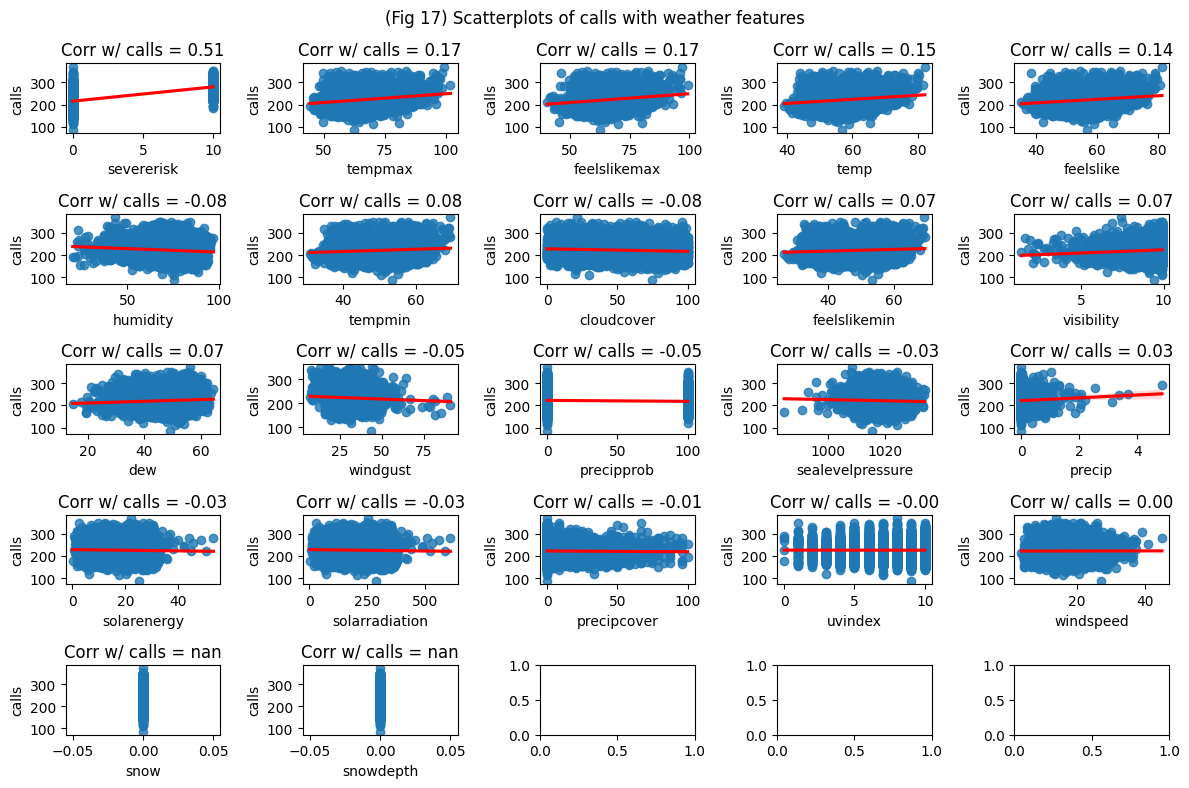

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(12,8))
sorted_weather_feats = list(corr.calls.abs().sort_values(ascending=False).index)[1:]
for i in range(len(sorted_weather_feats)):
    weather_feat = sorted_weather_feats[i]
    sns.regplot(train_weather, x=weather_feat, y='calls', ax=axs[i//5][i%5],
                line_kws=dict(color="r"))
    axs[i//5][i%5].set_title(f'Corr w/ calls = {corr.calls[weather_feat]:.2f}')
plt.suptitle('(Fig 17) Scatterplots of calls with weather features');
plt.tight_layout()

From figures 16 and 17, we can see that `severerisk` has by far the highest correlation with calls, followed by temperature-related features. `severerisk`, according to the [documentation](https://www.visualcrossing.com/resources/documentation/weather-data/weather-data-documentation/), is a measure of the risk of storms and is a unit-less metric that takes into account many weather variables. However, as we can see below, it seems like `severerisk` is almost always 10 in our training data from 2022 and on, so its correlation with EMS calls from figure 17 must simply be because EMS call demand overall was lower in previous years in our training data.

In [409]:
print("Fraction of days with severerisk == 10:")
train_weather.groupby('year').severerisk.mean()/10

Fraction of days with severerisk == 10:


year
2006    0.000000
2007    0.000000
2008    0.000000
2009    0.000000
2010    0.000000
2011    0.000000
2012    0.000000
2013    0.000000
2014    0.000000
2015    0.000000
2016    0.000000
2017    0.000000
2018    0.000000
2019    0.000000
2020    0.000000
2021    0.000000
2022    0.975477
2023    1.000000
Name: severerisk, dtype: float64

The other potentially meaningful weather features are temperature related (temp min/max, etc), and figure 19 below shows some potentially meaningful 2-degree polynomial relationships between weather variables and calls. A polynomial could make sense if both extreme low and high temperatures lead to more EMS calls.


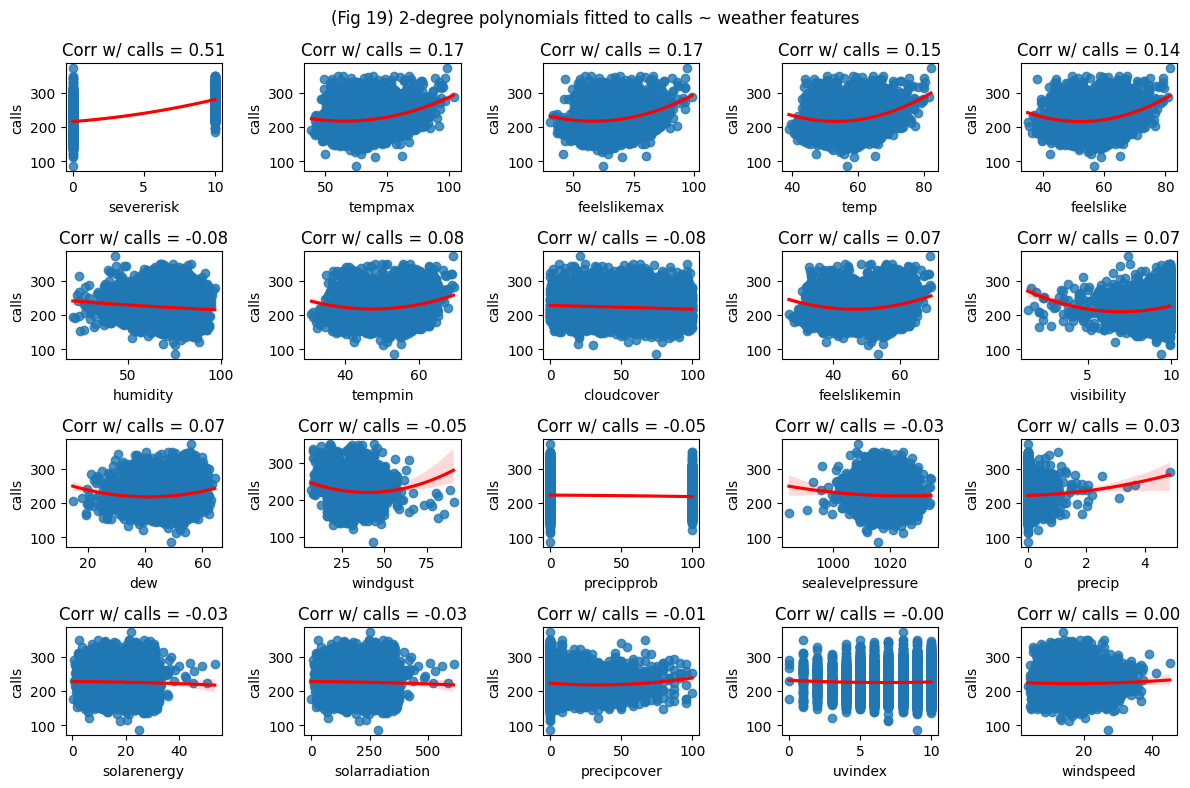

In [336]:
fig, axs = plt.subplots(4, 5, figsize=(12,8))
sorted_weather_feats = list(corr.calls.abs().sort_values(ascending=False).index)[1:21]
for i in range(len(sorted_weather_feats)):
    weather_feat = sorted_weather_feats[i]
    sns.regplot(train_weather, x=weather_feat, y='calls', ax=axs[i//5][i%5],
                line_kws=dict(color="r"), order=2)
    axs[i//5][i%5].set_title(f'Corr w/ calls = {corr.calls[weather_feat]:.2f}')
plt.suptitle('(Fig 19) 2-degree polynomials fitted to calls ~ weather features');
plt.tight_layout()

Additionally, figure 20 shows that the correlation between tempmax and EMS calls changes over the years, most significantly in 2020 which is the only year where the correlation is actually negative. Let's see if removing the year of 2020 improves our model's performance on our validation set (which has data from 10/2023-10/2024).

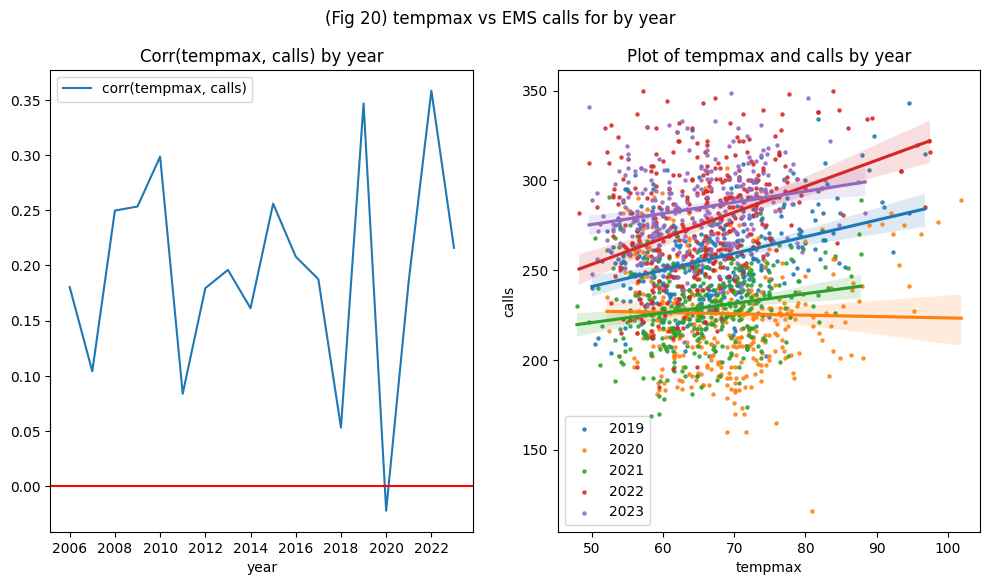

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))
train_weather.groupby('year')[['tempmax', 'calls']].corr().xs('tempmax', level=1)[['calls']].rename(
  columns={'calls': 'corr(tempmax, calls)'}).plot(ax=axs[0])
axs[0].set_xticks(list(range(2006, 2024, 2)))
axs[0].axhline(y=0, color='red')
axs[0].set_title('Corr(tempmax, calls) by year')

for year in range(2019, 2024):
  sns.regplot(train_weather[train_weather.year == year], x='tempmax', y='calls', 
    scatter_kws={"s": 5}, ax=axs[1], label=year)
axs[1].legend()
axs[1].set_title('Plot of tempmax and calls by year')
fig.suptitle('(Fig 20) tempmax vs EMS calls for by year');

Top 15 features:
                             feature  coefficient
0                       scaler__lag1    64.517876
7                      scaler__lag14    44.293148
12                      scaler__temp    35.820542
10                   scaler__tempmax    34.228976
6                       scaler__lag7    31.907881
8                      scaler__lag21    31.075314
1                       scaler__lag2    30.680236
5                       scaler__lag6    23.404820
14              scaler__feelslikemin   -22.659337
2                       scaler__lag3    17.126739
4                       scaler__lag5    12.035206
52            cyclic_week__week_sp_8   -11.237036
18                    scaler__precip    11.011868
53            cyclic_week__week_sp_9    10.172805
43  cyclic_dayofweek__dayofweek_sp_6    10.156582
Used 73/96 features
RMSE: 22.93
MAPE: 0.0679
MAE: 18.1920
Used 46 features to represent week of year
Used 6 features to represent month
Used 5 features to represent day of week


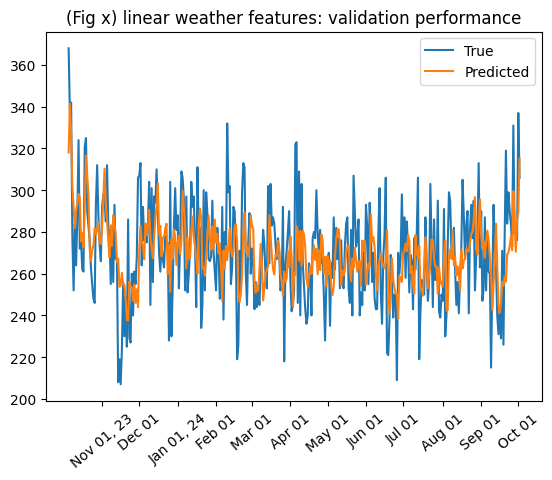

In [16]:
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols
valid_weather = pd.merge(valid.drop(['tempmax', 'cloudcover'], axis=1),
                         weather, left_on='received_date', right_on='datetime', how='left')
X_train_weather, y_train = train_weather[feats], train_weather.calls
X_valid_weather, y_valid = valid_weather[feats], valid_weather.calls

transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_weather, y_train)
eval_lasso(model, X_valid_weather, y_valid, PlotArgs('x', 'linear weather features'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')

Top 15 features:
                              feature  coefficient
135        numerical__remainder__lag1    63.326164
17      numerical__poly__tempmax temp    50.742933
142       numerical__remainder__lag14    44.662101
141        numerical__remainder__lag7    32.012489
143       numerical__remainder__lag21    30.795453
136        numerical__remainder__lag2    30.598189
140        numerical__remainder__lag6    23.624095
137        numerical__remainder__lag3    17.196032
44            numerical__poly__temp^2    12.278119
172            cyclic_week__week_sp_8   -12.029230
139        numerical__remainder__lag5    11.947516
15         numerical__poly__tempmax^2    11.918208
173            cyclic_week__week_sp_9    10.439973
138        numerical__remainder__lag4    10.125533
163  cyclic_dayofweek__dayofweek_sp_6    10.096022
Used 93/216 features
RMSE: 22.84
MAPE: 0.0679
MAE: 18.1709
Used 47 features to represent week of year
Used 6 features to represent month
Used 5 features to represent d

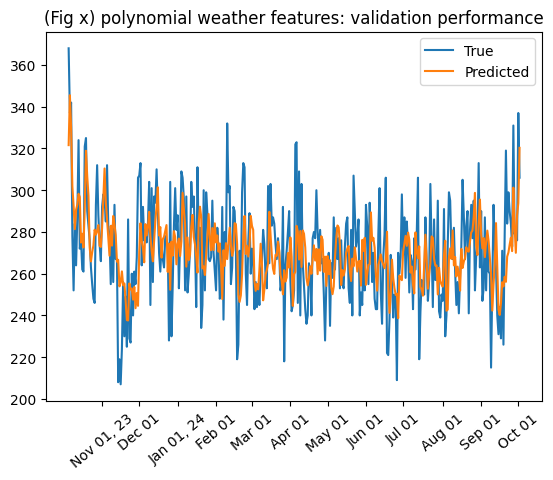

In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols
valid_weather = pd.merge(valid.drop(['tempmax', 'cloudcover'], axis=1),
                         weather, left_on='received_date', right_on='datetime', how='left')
X_train_weather, y_train = train_weather[feats], train_weather.calls
X_valid_weather, y_valid = valid_weather[feats], valid_weather.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_weather, y_train)
eval_lasso(model, X_valid_weather, y_valid, PlotArgs('x', 'polynomial weather features'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

Top 15 features:
                                            feature  coefficient
135                      numerical__remainder__lag1    62.052276
17                    numerical__poly__tempmax temp    46.180247
142                     numerical__remainder__lag14    43.879450
143                     numerical__remainder__lag21    32.712712
141                      numerical__remainder__lag7    31.993584
136                      numerical__remainder__lag2    30.169644
140                      numerical__remainder__lag6    22.102363
137                      numerical__remainder__lag3    18.333422
21                     numerical__poly__tempmax dew    16.406040
15                       numerical__poly__tempmax^2    15.697003
77   numerical__poly__feelslikemin sealevelpressure   -14.827813
172                          cyclic_week__week_sp_8   -12.144402
139                      numerical__remainder__lag5    11.705618
213                         cyclic_week__week_sp_49    10.676318
163     

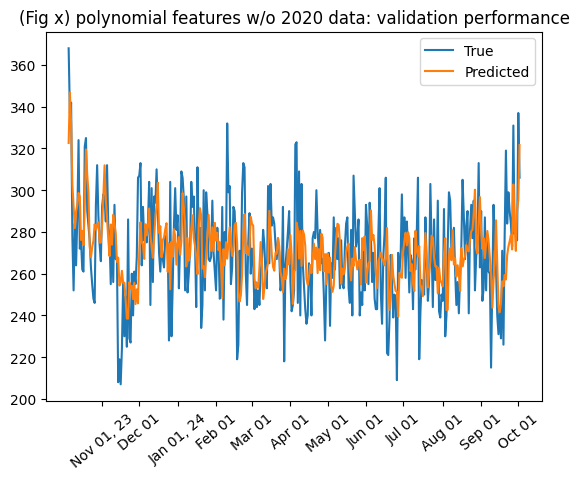

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols
valid_weather = pd.merge(valid.drop(['tempmax', 'cloudcover'], axis=1),
                         weather, left_on='received_date', right_on='datetime', how='left')
train_weather1 = train_weather[train_weather.year != 2020]
X_train_weather, y_train = train_weather1[feats], train_weather1.calls
X_valid_weather, y_valid = valid_weather[feats], valid_weather.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_weather, y_train)
eval_lasso(model, X_valid_weather, y_valid, PlotArgs('x', 'polynomial features w/o 2020 data'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

In [19]:
features = [
  'linear weather features',
  '2d polynomial weather features',
  '2d polynomial weather features + remove 2020 data',
]
num_features_selected = [73, 93, 90]
RMSE = [22.93, 22.84, 22.81]
MAE = [18.19, 18.17, 18.14]
MAPE = [0.068, 0.068, 0.068]
print('Results with LR with L1 regularization')
pd.DataFrame({
  'features': features,
  '# features selected from L1 regularization': num_features_selected,
  'RMSE': RMSE, 'MAE': MAE, 'MAPE': MAPE
})

Results with LR with L1 regularization


,features,# features selected from L1 regularization,RMSE,MAE,MAPE
0,linear weather features,73,22.93,18.19,0.068
1,2d polynomial weather features,93,22.84,18.17,0.068
2,2d polynomial weather features + remove 2020 data,90,22.81,18.14,0.068


From the above, we can see that using 2d polynomial weather features does perform better than linear weather features, though at the cost of 20 more features. We can also see that removing 2020 data does improve model performance slightly, which is evidence that the nature of EMS call demand was substantially different in 2020 than in other years, probably due to Covid lockdowns and people moving out of SF.

## Exploring special events
Much of the EMS demand forecasting [literature](#references) mention the potential usefulness of indicators of holidays or special events for predicting EMS demand. In figure 21, we'll look at the relationship between EMS calls and holidays (Christmas, Thanksgiving, July 4th, New Years) and the following annual special events in SF: Bay to Breakers, SF Marathon, Chinese New Years Parade, St. Patrick's Day Parade, Outside Lands, Pride Parade. "None" encode days that are neither holidays nor special events.

In [20]:
giants_games = pd.read_csv('raw_data_analysis/giants_games.csv')
warriors_games = pd.read_csv('raw_data_analysis/warriors_games.csv')
niners_games = pd.read_csv('raw_data_analysis/niners_games.csv')
giants_games.date = pd.to_datetime(giants_games.date)
warriors_games.date = pd.to_datetime(warriors_games.date)
niners_games.date = pd.to_datetime(niners_games.date)
train_events = pd.merge(train_weather, warriors_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'warriors_home_game', 'playoff_game': 'warriors_playoff_game'})\
    .drop(labels=['date'], axis=1)
train_events = pd.merge(train_events, giants_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'giants_home_game'})\
    .drop(labels=['date'], axis=1)
train_events = pd.merge(train_events, niners_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'niners_home_game'})\
    .drop(labels=['date'], axis=1)
train_events.warriors_home_game = train_events.warriors_home_game.fillna(-1)
train_events.warriors_playoff_game = train_events.warriors_playoff_game.fillna(-1)
train_events.giants_home_game = train_events.giants_home_game.fillna(-1)
train_events.niners_home_game = train_events.niners_home_game.fillna(-1)

special_events = pd.read_csv('raw_data_analysis/special-events.csv')
special_events.date = pd.to_datetime(special_events.date)
# make sure all events are on unique days before merging
assert special_events.shape[0] == special_events.date.nunique()
train_events = pd.merge(train_events, special_events, left_on='received_date', right_on='date', how='left')\
    .drop(labels=['date'], axis=1).rename(columns={'name_y': 'event'})
train_events.event = train_events.event.fillna('None')


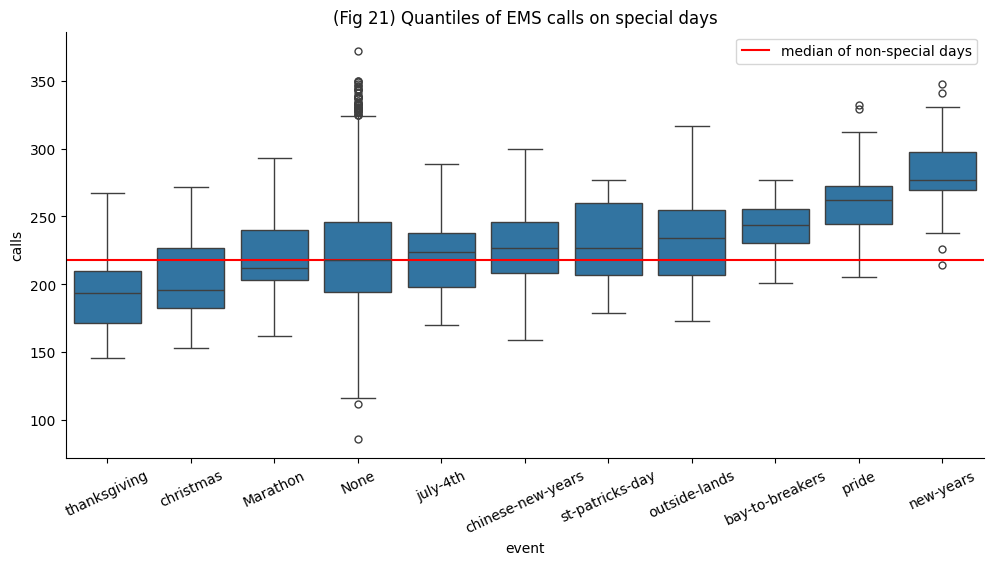

In [21]:
event_calls = train_events.groupby('event').calls.median().sort_values()
sns.catplot(train_events, y="calls", x="event", kind="box", order=event_calls.index,
            legend_out=True, aspect=2)
plt.axhline(y=event_calls['None'], color='r', label='median of non-special days')
plt.xticks(rotation=25)
plt.legend()
plt.title('(Fig 21) Quantiles of EMS calls on special days');

Below, we use the Kruskal-Wallis H test, which is a non-parametric test for testing if samples come from the same distribution. Particularly, the null hypothesis is that the median of all groups is the same. The p-value for this test is sufficiently small to reject the null hypothesis, so we move on to the post hoc Dunn's test (with bonferroni correction since we're in a multiple hypothesis test setting) to see which groups are significantly different from our "control" group, which is EMS call demand for non-special days.

In [535]:
from scipy.stats import kruskal
import scikit_posthocs as sp
event_calls = []
event_types = train_events.event.unique()
for event in event_types:
  event_calls.append(train_events[train_events.event == event].calls)
kruskal_results = kruskal(*event_calls)
print(f'Kruskal-Wallis test p-value: {kruskal_results.pvalue}')

dunn_results = sp.posthoc_dunn(event_calls, p_adjust='bonferroni')
dunn_results.index, dunn_results.columns = event_types, event_types
print()

print('Corrected p-values for Mann Whitney test comparing each group to the control:')
dunn_results['None'][dunn_results['None'].index != 'None']

Kruskal-Wallis test p-value: 1.6390159802626836e-18

Corrected p-values for Mann Whitney test comparing each group to the control:


new-years            2.028482e-06
chinese-new-years    1.000000e+00
st-patricks-day      1.000000e+00
bay-to-breakers      3.783433e-01
pride                2.313728e-07
july-4th             1.000000e+00
Marathon             1.000000e+00
thanksgiving         1.318789e-03
christmas            1.942882e-01
outside-lands        2.603277e-01
Name: None, dtype: float64

From these tests, we have evidence that the difference in EMS call demand (from non-special days) during Thanksgiving, New Years, and Pride Parades is not due to random chance.

In [22]:
def add_special_day_to_data(event_type, event_name, data):
  special_day_df = special_events[special_events.name == event_type]
  special_day_df.loc[:, event_name] = 1
  new_data = pd.merge(data, special_day_df, left_on='received_date', right_on='date', how='left')\
        .drop(labels=['date', 'name'], axis=1)
  new_data.loc[:, event_name] = new_data.loc[:, event_name].fillna(0)
  return new_data
train_events_final = add_special_day_to_data('thanksgiving', 'thanksgiving', train_events.drop(labels=['new_years', 'pride', 'thanksgiving'], axis=1))
train_events_final = add_special_day_to_data('new-years', 'new_years', train_events_final)
train_events_final = add_special_day_to_data('pride', 'pride', train_events_final)
valid_events = add_special_day_to_data('thanksgiving', 'thanksgiving', valid_weather.drop(labels=['new_years', 'pride', 'thanksgiving', 'name'], axis=1))
valid_events = add_special_day_to_data('new-years', 'new_years', valid_events)
valid_events = add_special_day_to_data('pride', 'pride', valid_events)

Top 15 features:
                                            feature  coefficient
217                            remainder__new_years    67.815918
135                      numerical__remainder__lag1    57.659080
142                     numerical__remainder__lag14    43.342684
218                                remainder__pride    39.153804
17                    numerical__poly__tempmax temp    36.774702
141                      numerical__remainder__lag7    35.255728
136                      numerical__remainder__lag2    31.929441
143                     numerical__remainder__lag21    28.851928
15                       numerical__poly__tempmax^2    26.163672
216                         remainder__thanksgiving   -23.278973
140                      numerical__remainder__lag6    23.201487
137                      numerical__remainder__lag3    20.423792
77   numerical__poly__feelslikemin sealevelpressure   -15.317393
139                      numerical__remainder__lag5    13.680015
172     

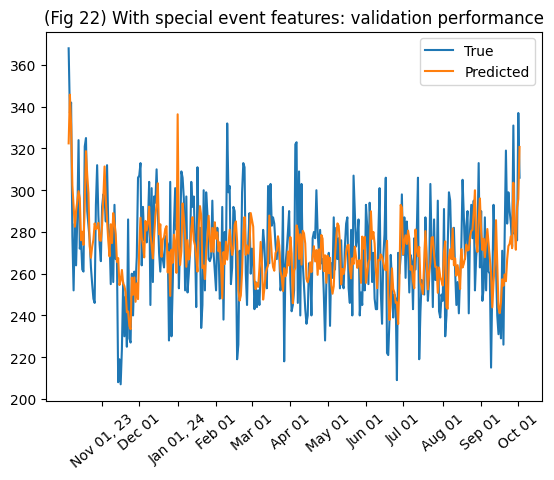

In [23]:
special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_events, y_train_events)
eval_lasso(model, X_valid_events, y_valid_events, PlotArgs('22', 'With special event features'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

In [27]:
sorted(list(zip(feats, reg.coef_)), key=lambda x: -abs(x[1]))

[('remainder__new_years', np.float64(67.8159175229339)),
 ('numerical__remainder__lag1', np.float64(57.65907964324421)),
 ('numerical__remainder__lag14', np.float64(43.342683835840546)),
 ('remainder__pride', np.float64(39.15380444395662)),
 ('numerical__poly__tempmax temp', np.float64(36.7747022250464)),
 ('numerical__remainder__lag7', np.float64(35.25572777815592)),
 ('numerical__remainder__lag2', np.float64(31.929440993311406)),
 ('numerical__remainder__lag21', np.float64(28.85192779140562)),
 ('numerical__poly__tempmax^2', np.float64(26.16367209377208)),
 ('remainder__thanksgiving', np.float64(-23.27897329045815)),
 ('numerical__remainder__lag6', np.float64(23.201486873088456)),
 ('numerical__remainder__lag3', np.float64(20.423792397584062)),
 ('numerical__poly__feelslikemin sealevelpressure',
  np.float64(-15.317392771991235)),
 ('numerical__remainder__lag5', np.float64(13.68001515176125)),
 ('cyclic_week__week_sp_8', np.float64(-11.7348968632704)),
 ('cyclic_week__week_sp_9', np.

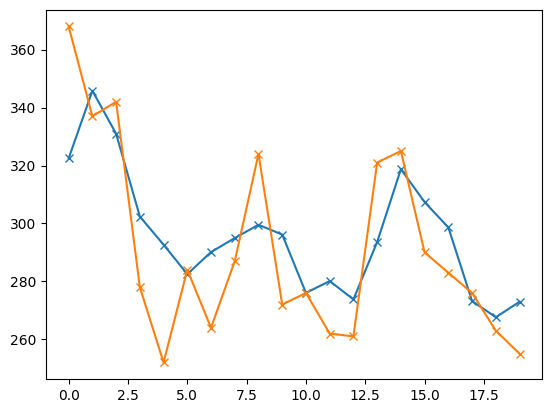

In [29]:
plt.plot(model.predict(X_valid_events.iloc[:20]), marker='x')
plt.plot(y_valid_events.iloc[:20], marker='x')

In [42]:
valid.head()

,received_date,calls,dayofweek,month,year,week,season,lag1,lag2,lag3,...,lag6,lag7,lag14,lag21,tempmax,cloudcover,giants_game,new_years,pride,thanksgiving
6946,2023-10-05,368,3,10,2023,40,3,322.0,295.0,281.0,...,317.0,301.0,288.0,297.0,89.3,0.0,none,0.0,0.0,0.0
6947,2023-10-06,337,4,10,2023,40,3,368.0,322.0,295.0,...,306.0,317.0,304.0,308.0,90.4,1.5,none,0.0,0.0,0.0
6948,2023-10-07,342,5,10,2023,40,3,337.0,368.0,322.0,...,273.0,306.0,287.0,300.0,87.5,0.0,none,0.0,0.0,0.0
6949,2023-10-08,278,6,10,2023,40,3,342.0,337.0,368.0,...,281.0,273.0,301.0,269.0,69.4,26.7,none,0.0,0.0,0.0
6950,2023-10-09,252,0,10,2023,41,3,278.0,342.0,337.0,...,295.0,281.0,318.0,284.0,69.8,90.8,none,0.0,0.0,0.0


<Axes: ylabel='Frequency'>

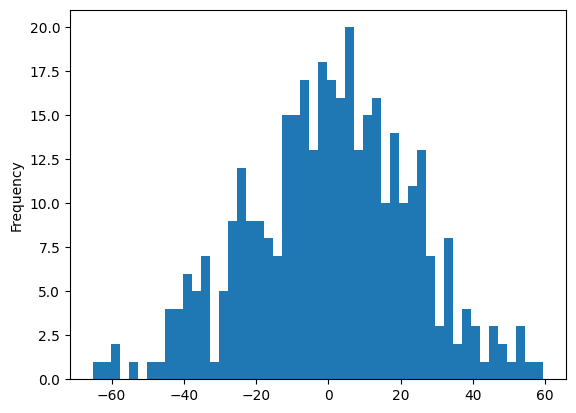

In [44]:
resids = model.predict(X_valid_events) - y_valid_events
X_valid_copy = X_valid_events.copy()

valid_received = valid[['received_date']].copy()
valid_received.index = X_valid_events.index
X_valid_copy = pd.concat([X_valid_copy,valid_received], axis=1)
X_valid_copy.loc[:,'preds'] = model.predict(X_valid_events)
X_valid_copy.loc[:,'obs'] = y_valid_events
X_valid_copy.loc[:,'resid'] = X_valid_copy.preds - X_valid_copy.obs
X_valid_copy.resid.plot.hist(bins=50)

In [51]:
x = X_valid_copy[X_valid_copy.resid > 30]
x.dayofweek.value_counts()

dayofweek
2    6
0    5
3    4
4    4
1    4
6    4
5    4
Name: count, dtype: int64

In [52]:
x.month.value_counts()

month
11    5
4     4
8     4
12    3
6     3
10    2
1     2
2     2
5     2
7     2
3     1
9     1
Name: count, dtype: int64

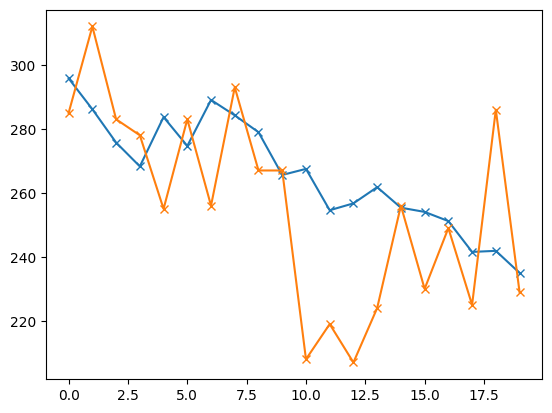

In [49]:
plt.plot(model.predict(X_valid_events.iloc[30:50]), marker='x')
y = y_valid_events.iloc[30:50]
y.index = list(range(len(y)))
plt.plot(y, marker='x')

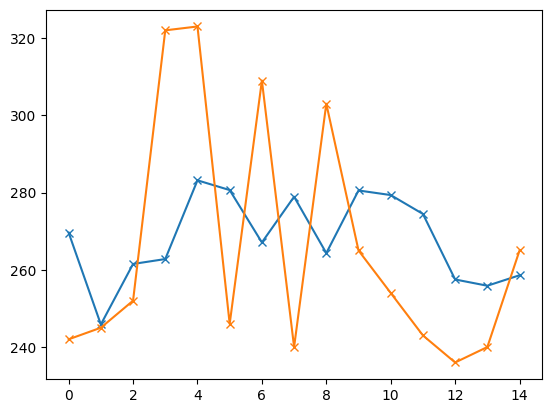

In [50]:
plt.plot(model.predict(X_valid_events.iloc[180:195]), marker='x')
y = y_valid_events.iloc[180:195]
y.index = list(range(len(y)))
plt.plot(y, marker='x')

In [53]:
x[x.month == 4]

,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,lag21,year,...,dayofweek,month,week,thanksgiving,new_years,pride,received_date,preds,obs,resid
185,323.0,322.0,252.0,245.0,242.0,257.0,290.0,252.0,283.0,2024,...,6,4,14,0.0,0.0,0.0,2024-04-07,280.642072,246,34.642072
187,309.0,246.0,323.0,322.0,252.0,245.0,242.0,292.0,284.0,2024,...,1,4,15,0.0,0.0,0.0,2024-04-09,278.915813,240,38.915813
191,254.0,265.0,303.0,240.0,309.0,246.0,323.0,280.0,270.0,2024,...,5,4,15,0.0,0.0,0.0,2024-04-13,274.456943,243,31.456943
207,250.0,267.0,265.0,281.0,270.0,280.0,300.0,240.0,309.0,2024,...,0,4,18,0.0,0.0,0.0,2024-04-29,268.823600,228,40.823600


In [54]:
X_valid_copy.iloc[180:195]

,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,lag21,year,...,dayofweek,month,week,thanksgiving,new_years,pride,received_date,preds,obs,resid
180,257.0,290.0,280.0,271.0,264.0,218.0,292.0,284.0,258.0,2024,...,1,4,14,0.0,0.0,0.0,2024-04-02,269.616706,242,27.616706
181,242.0,257.0,290.0,280.0,271.0,264.0,218.0,274.0,253.0,2024,...,2,4,14,0.0,0.0,0.0,2024-04-03,245.840242,245,0.840242
182,245.0,242.0,257.0,290.0,280.0,271.0,264.0,267.0,302.0,2024,...,3,4,14,0.0,0.0,0.0,2024-04-04,261.507412,252,9.507412
183,252.0,245.0,242.0,257.0,290.0,280.0,271.0,277.0,265.0,2024,...,4,4,14,0.0,0.0,0.0,2024-04-05,262.781453,322,-59.218547
184,322.0,252.0,245.0,242.0,257.0,290.0,280.0,270.0,303.0,2024,...,5,4,14,0.0,0.0,0.0,2024-04-06,283.162596,323,-39.837404
185,323.0,322.0,252.0,245.0,242.0,257.0,290.0,252.0,283.0,2024,...,6,4,14,0.0,0.0,0.0,2024-04-07,280.642072,246,34.642072
186,246.0,323.0,322.0,252.0,245.0,242.0,257.0,256.0,287.0,2024,...,0,4,15,0.0,0.0,0.0,2024-04-08,267.081055,309,-41.918945
187,309.0,246.0,323.0,322.0,252.0,245.0,242.0,292.0,284.0,2024,...,1,4,15,0.0,0.0,0.0,2024-04-09,278.915813,240,38.915813
188,240.0,309.0,246.0,323.0,322.0,252.0,245.0,218.0,274.0,2024,...,2,4,15,0.0,0.0,0.0,2024-04-10,264.317201,303,-38.682799
189,303.0,240.0,309.0,246.0,323.0,322.0,252.0,264.0,267.0,2024,...,3,4,15,0.0,0.0,0.0,2024-04-11,280.536545,265,15.536545


In [55]:
X_valid_copy.tempmin

0      61.4
1      63.3
2      63.7
3      57.7
4      57.2
       ... 
360    58.7
361    58.0
362    54.7
363    61.4
364    64.0
Name: tempmin, Length: 365, dtype: float64

Top 15 features:
                            feature  coefficient
91             remainder__new_years    67.509135
3   numerical__poly__feelslikemax^2    61.734399
9        numerical__remainder__lag1    59.248176
16      numerical__remainder__lag14    43.083850
92                 remainder__pride    39.068177
15       numerical__remainder__lag7    35.056658
10       numerical__remainder__lag2    31.631386
17      numerical__remainder__lag21    29.566913
14       numerical__remainder__lag6    23.230941
90          remainder__thanksgiving   -23.165206
11       numerical__remainder__lag3    19.855742
13       numerical__remainder__lag5    13.882417
47           cyclic_week__week_sp_9    11.481553
46           cyclic_week__week_sp_8   -11.469707
87          cyclic_week__week_sp_49    11.085238
Used 74/93 features
RMSE: 22.7
MAPE: 0.0676
MAE: 18.0856
Used 48 features to represent week of year
Used 8 features to represent month
Used 5 features to represent day of week
Used 5 weather features

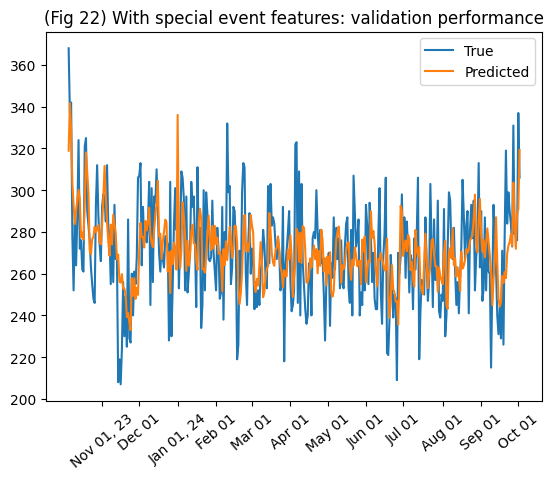

In [124]:
special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
'feelslikemax', 'feelslikemin', 'windspeed'
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_events, y_train_events)
eval_lasso(model, X_valid_events, y_valid_events, PlotArgs('22', 'With special event features'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

In [100]:
feats[reg.coef_ == 0]

array(['numerical__poly__windspeed',
       'numerical__poly__feelslikemax feelslikemin',
       'numerical__poly__feelslikemax windspeed',
       'numerical__poly__feelslikemin^2', 'cyclic_month__month_sp_0',
       'cyclic_month__month_sp_4', 'cyclic_month__month_sp_6',
       'cyclic_month__month_sp_9', 'cyclic_dayofweek__dayofweek_sp_0',
       'cyclic_dayofweek__dayofweek_sp_4', 'cyclic_week__week_sp_1',
       'cyclic_week__week_sp_3', 'cyclic_week__week_sp_7',
       'cyclic_week__week_sp_13', 'cyclic_week__week_sp_29',
       'cyclic_week__week_sp_30', 'cyclic_week__week_sp_37',
       'cyclic_week__week_sp_39', 'cyclic_week__week_sp_42'], dtype=object)

In [ ]:
train_transformed = pd.DataFrame(
  transformer.transform(X_train_events),
  columns=transformer.get_feature_names_out())
train_transformed.head()

,numerical__poly__feelslikemax,numerical__poly__feelslikemin,numerical__poly__windspeed,numerical__poly__feelslikemax^2,numerical__poly__feelslikemax feelslikemin,numerical__poly__feelslikemax windspeed,numerical__poly__feelslikemin^2,numerical__poly__feelslikemin windspeed,numerical__poly__windspeed^2,numerical__remainder__lag1,...,cyclic_week__week_sp_45,cyclic_week__week_sp_46,cyclic_week__week_sp_47,cyclic_week__week_sp_48,cyclic_week__week_sp_49,cyclic_week__week_sp_50,cyclic_week__week_sp_51,remainder__thanksgiving,remainder__new_years,remainder__pride
0,0.306878,0.441589,0.561743,0.219167,0.255011,0.563907,0.331422,0.554587,0.352964,0.486014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,1.0,0.0
1,0.236332,0.598131,0.452785,0.161909,0.287472,0.414275,0.490742,0.526656,0.242663,0.657343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.253968,0.390187,0.307506,0.175838,0.208413,0.283171,0.283883,0.290432,0.126917,0.283217,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.389771,0.593458,0.222760,0.291690,0.367466,0.243604,0.485669,0.270357,0.075931,0.419580,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.340388,0.455607,0.125908,0.247802,0.277167,0.125970,0.344797,0.136363,0.032576,0.534965,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [76]:
feat_coefs = pd.DataFrame([[x[0], x[1]] for x in list(zip(feats, reg.coef_))], columns=['feat', 'coef'])

In [77]:
weather_vals = pd.Series([0]*len(train_transformed))
for f in feats:
  if 'numerical__poly' in f:
    weather_vals += train_transformed[f]*feat_coefs[feat_coefs.feat == f].coef.iloc[0]

<Axes: xlabel='weather_val', ylabel='calls'>

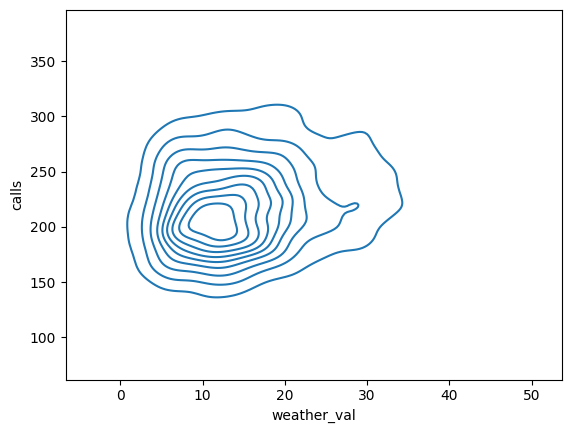

In [80]:
x = pd.DataFrame({
  'weather_val': weather_vals, 'calls': y_train_events
})
sns.kdeplot(x, x='weather_val', y='calls')

RMSE: 22.69
MAPE: 0.0675
MAE: 18.0613


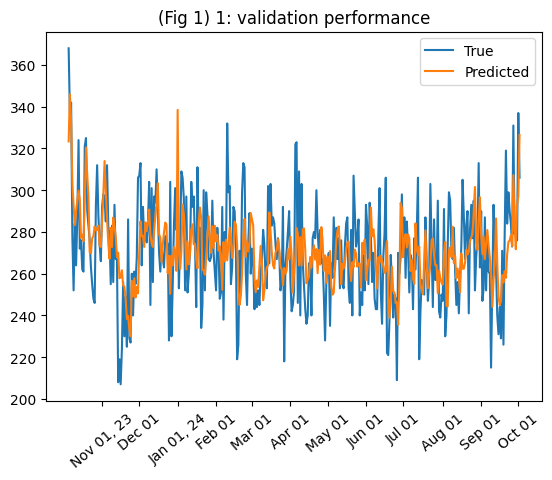

In [127]:
special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
'feelslikemax', 'feelslikemin', 'windspeed'
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')
from sklearn.feature_selection import SelectFromModel


modelt = make_pipeline(transformer, SelectFromModel(model.named_steps['lassocv'], prefit=True), RidgeCV(cv=ts_cv))
modelt.fit(X_train_events, y_train_events)
validation_metrics(y_valid_events, modelt.predict(X_valid_events), PlotArgs('1', '1'))

# eval_lasso(model, X_valid_events, y_valid_events, PlotArgs('22', 'With special event features'), transformer)
# reg = model.named_steps['lassocv']
# feats = transformer.get_feature_names_out()
# used_feats = feats[reg.coef_ != 0]

# print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
# print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
# print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
# print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

In [135]:
plt.rcParams['figure.figsize'] = [12,8]

RMSE: 22.5
MAPE: 0.0674
MAE: 18.0183


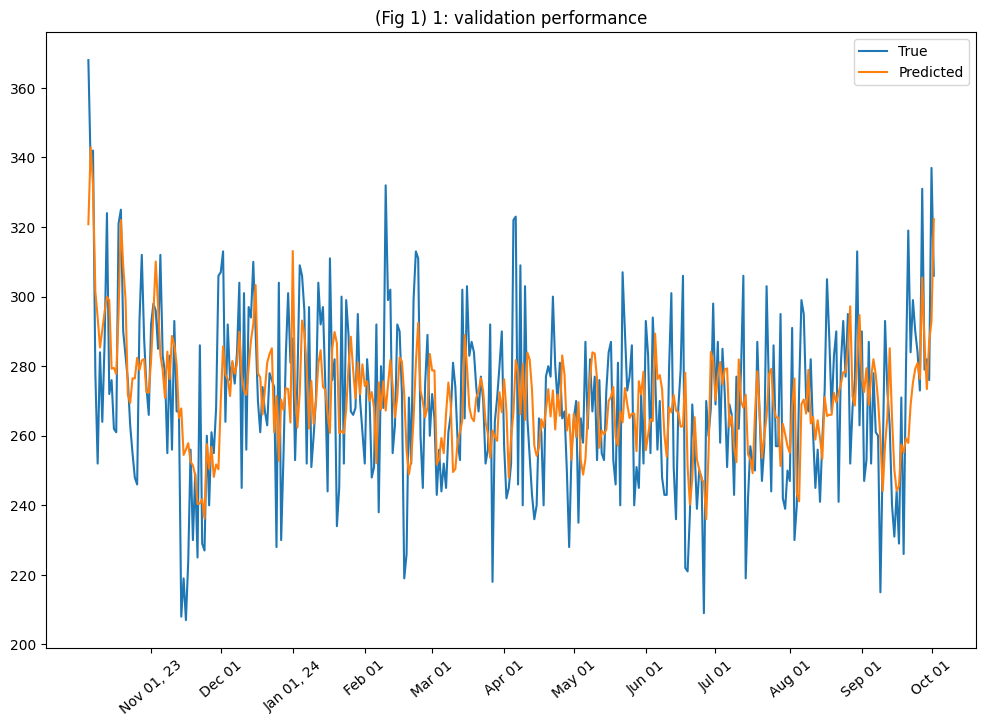

In [166]:
special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
'feelslikemax', 'feelslikemin', 'windspeed'
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls


from sklearn.preprocessing import StandardScaler
numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', StandardScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(8), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(4), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(35), ["week"]),
    ], remainder='passthrough')

from sklearn.linear_model import RidgeCV

model = make_pipeline(transformer, RidgeCV(cv=ts_cv))
model.fit(X_train_events, y_train_events)
validation_metrics(y_valid_events, model.predict(X_valid_events), PlotArgs('1', '1'))


RMSE: 18.96
MAPE: 0.0577
MAE: 15.4360


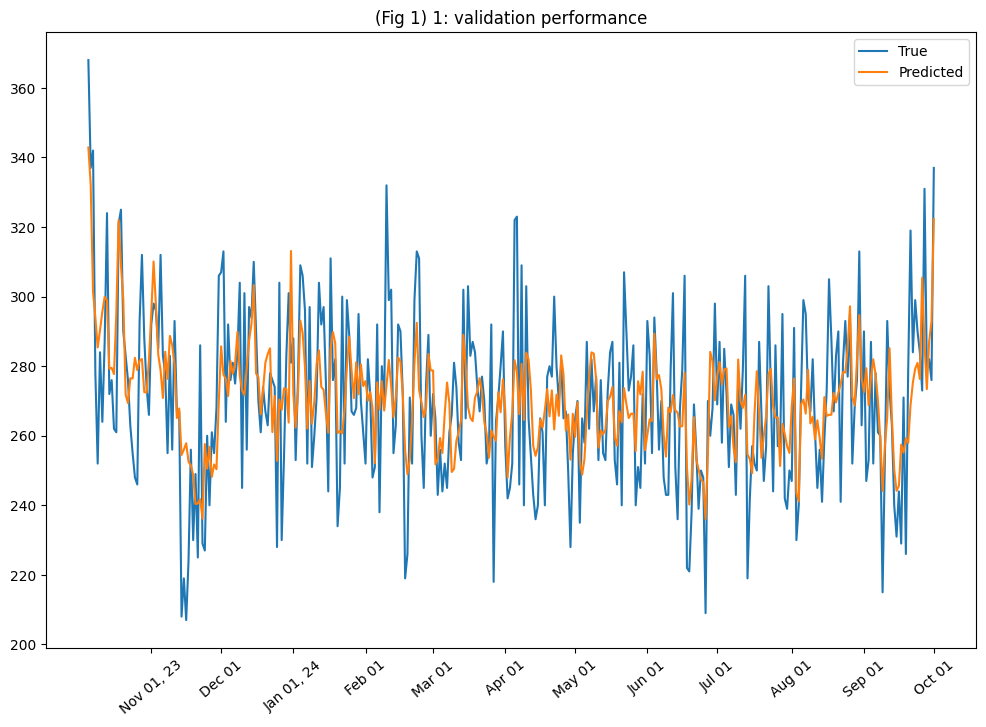

In [137]:
validation_metrics(y_valid_events[:-1], model.predict(X_valid_events)[1:], PlotArgs('1', '1'))


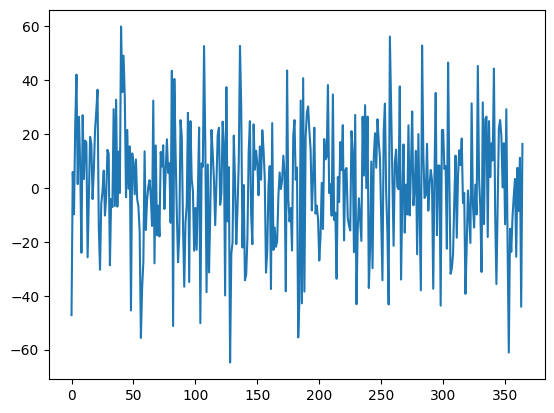

In [131]:
resids = model.predict(X_valid_events)- y_valid_events
plt.plot(resids)

In [132]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(resids)

,lb_stat,lb_pvalue
1,0.422787,0.515550
2,0.956324,0.619922
3,2.656129,0.447734
4,2.790829,0.593417
5,4.110929,0.533558
6,4.297992,0.636419
7,6.485835,0.484298
8,7.107389,0.525092
9,8.078492,0.526256
10,9.526766,0.482944


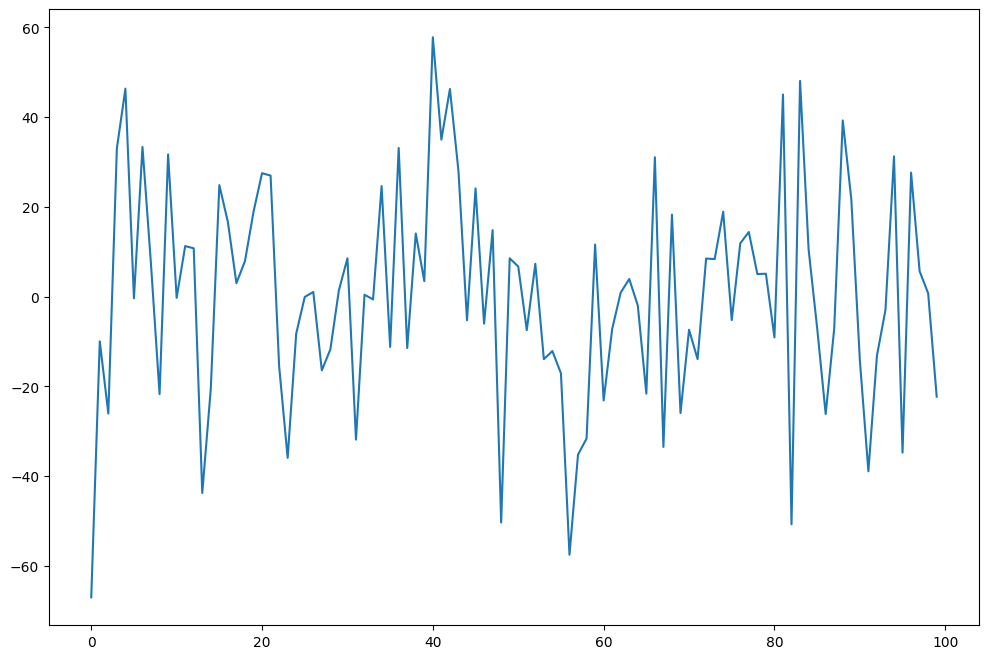

In [109]:
fig, ax = plt.subplots(figsize=(12,8))
X_valid_copy = X_valid_events.copy()
X_valid_copy.loc[:,'preds'] = model.predict(X_valid_events)
X_valid_copy.loc[:,'obs'] = y_valid_events
X_valid_copy.loc[:,'resid'] = X_valid_copy.preds - X_valid_copy.obs
plt.plot(X_valid_copy.resid[:100])

<Axes: ylabel='Frequency'>

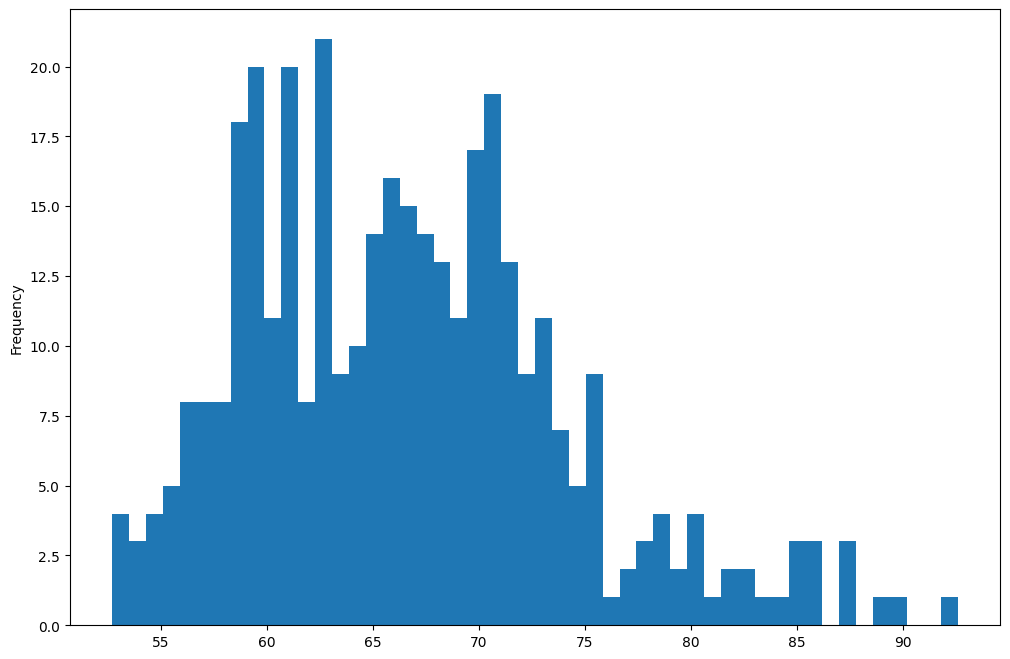

In [169]:
X_valid_events.feelslikemax.plot.hist(bins=50)

<Axes: ylabel='Frequency'>

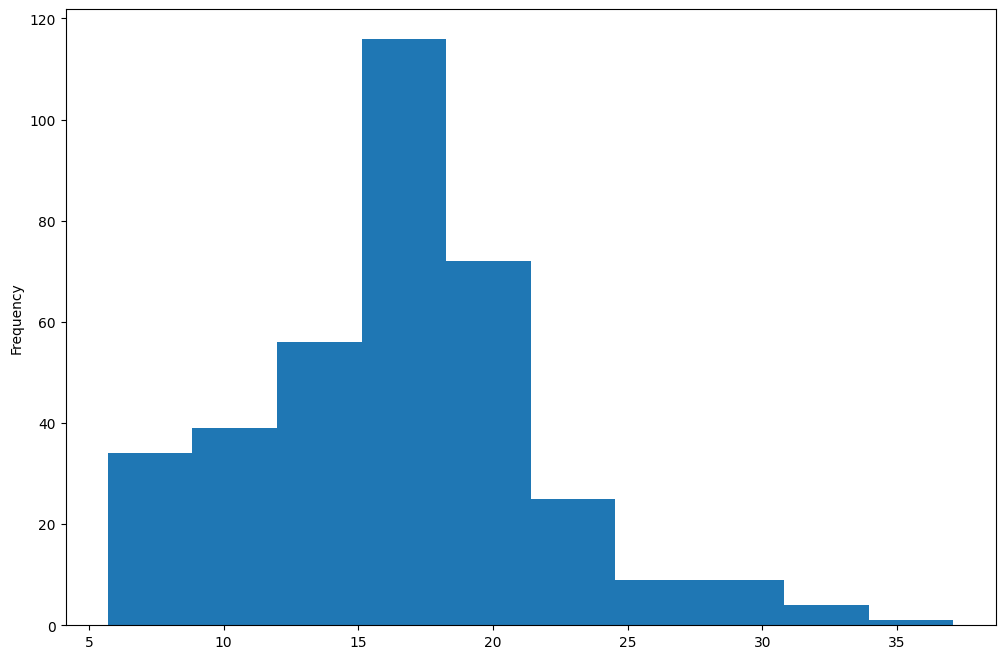

In [202]:
X_valid_events.windspeed.plot.hist()

In [ ]:
y_train_events.iloc[high_temp_i]

0      274
1      167
2      206
13     196
14     203
217    198
250    182
271    210
272    214
273    196
280    220
288    246
326    200
327    186
328    186
335    206
355    218
359    200
362    212
363    207
364    224
Name: calls, dtype: int64

In [182]:
# Perform the rolling forecast
sarima_preds = []
for step in range(len(valid.calls)):
    # Get 1-step-ahead forecast from the end of the current predictions
    forecast_val = arima_mod_res.get_forecast(steps=1).predicted_mean.iloc[0]
    sarima_preds.append(forecast_val)

    # Update the model with the new observation
    arima_mod_res = arima_mod_res.append(endog=[valid.calls.iloc[step]])
sarima_preds = np.array(sarima_preds)

RMSE: 34.57
MAPE: 0.0948
MAE: 28.4307
RMSE: 21.88
MAPE: 0.0628
MAE: 18.2453


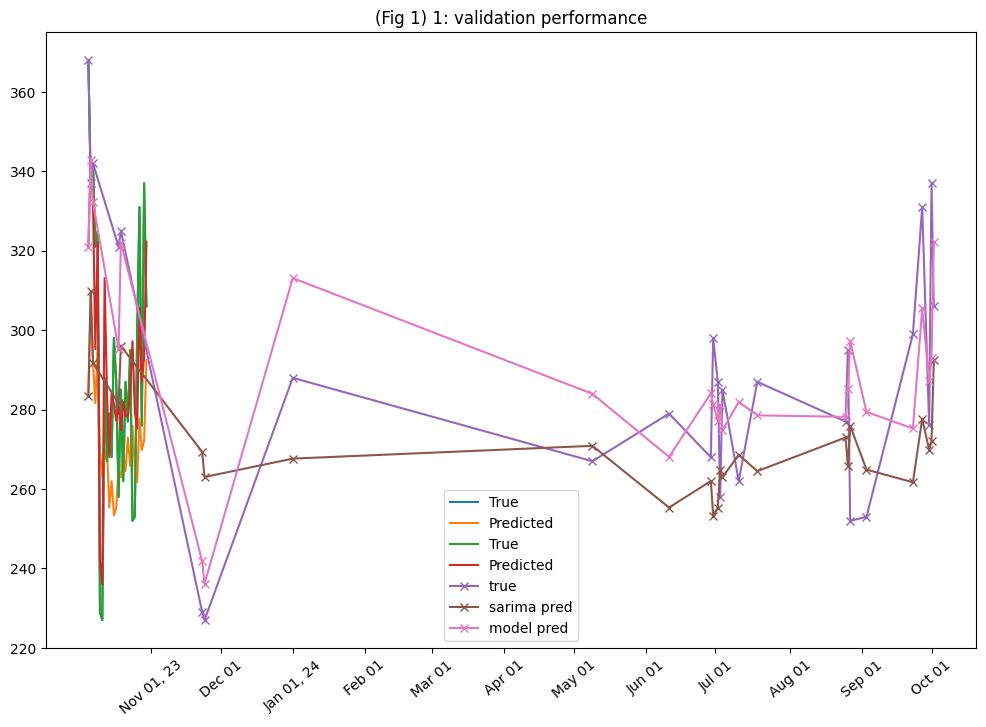

In [207]:
x = X_valid_events[(X_valid_events.new_years == 1) | (X_valid_events.thanksgiving == 1) | (X_valid_events.pride == 1) | (X_valid_events.feelslikemax > 80)]
high_temp_i = list(x.index)
obs = y_valid_events.iloc[high_temp_i]
s_preds = sarima_preds[high_temp_i]
model_preds = model.predict(x).flatten()
validation_metrics(obs, s_preds, PlotArgs('1', '1'))
validation_metrics(obs, model_preds, PlotArgs('1', '1'))
plt.plot(high_temp_i, obs,label='true', marker='x')
plt.plot(high_temp_i, s_preds, label='sarima pred', marker='x')
plt.plot(high_temp_i, model_preds,label= 'model pred', marker='x')
plt.legend()

In [128]:
X_valid_copy.head()

,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,year,dayofweek,month,thanksgiving,new_years,pride,preds,obs,resid
0,322.0,295.0,281.0,273.0,306.0,317.0,301.0,288.0,2023,3,10,0.0,0.0,0.0,301.026163,368,-66.973837
1,368.0,322.0,295.0,281.0,273.0,306.0,317.0,304.0,2023,4,10,0.0,0.0,0.0,327.056833,337,-9.943167
2,337.0,368.0,322.0,295.0,281.0,273.0,306.0,287.0,2023,5,10,0.0,0.0,0.0,315.972165,342,-26.027835
3,342.0,337.0,368.0,322.0,295.0,281.0,273.0,301.0,2023,6,10,0.0,0.0,0.0,311.041925,278,33.041925
4,278.0,342.0,337.0,368.0,322.0,295.0,281.0,318.0,2023,0,10,0.0,0.0,0.0,298.363934,252,46.363934


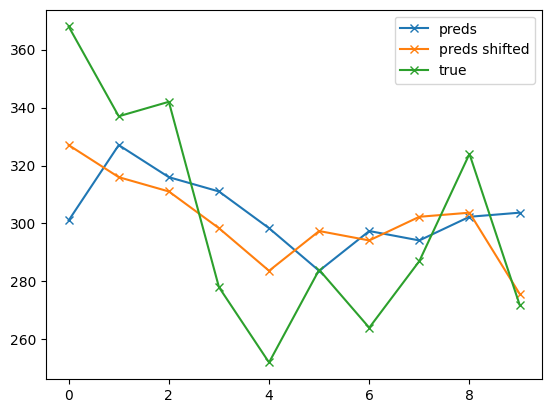

In [131]:
plt.plot(X_valid_copy.preds[:10], label='preds', marker='x')
x = X_valid_copy.preds[1:11]
x.index = list(range(10))
plt.plot(x, label='preds shifted', marker='x')
plt.plot(X_valid_copy.obs[:10], label='true', marker='x')
plt.legend();

In [95]:
m2.coef_, m2.intercept_

(array([1.00827354]), np.float64(-1.835177853298461))

<Axes: xlabel='obs', ylabel='preds'>

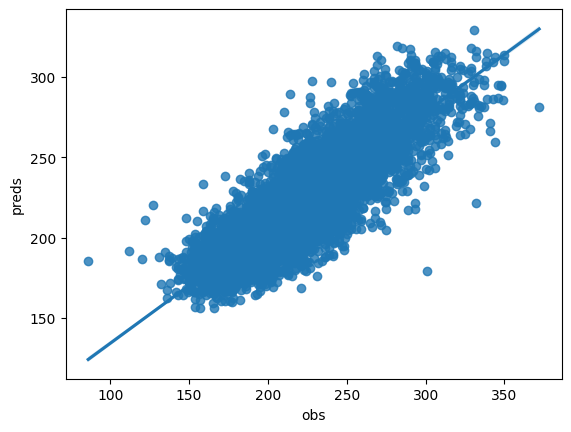

In [103]:
data = pd.DataFrame({
  'preds': m1.predict(X_train_events),
  'obs': y_train_events
})
import seaborn as sns
sns.regplot(data, x='obs', y='preds')

<Axes: xlabel='preds', ylabel='obs'>

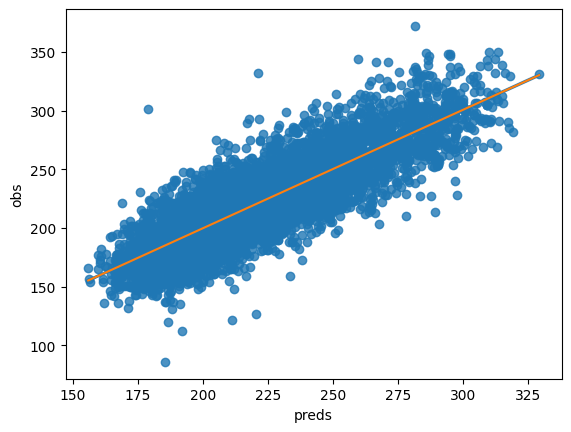

In [100]:
data = pd.DataFrame({
  'preds': m1.predict(X_train_events),
  'obs': y_train_events
})
import seaborn as sns
sns.regplot(data, x='preds', y='obs')
d2 = pd.DataFrame({
  'preds': m1.predict(X_train_events),
  'new_preds': 1.00827354*m1.predict(X_train_events)-1.835177853298461
})
sns.lineplot(d2, x='preds', y='new_preds')

<Axes: xlabel='obs', ylabel='resids'>

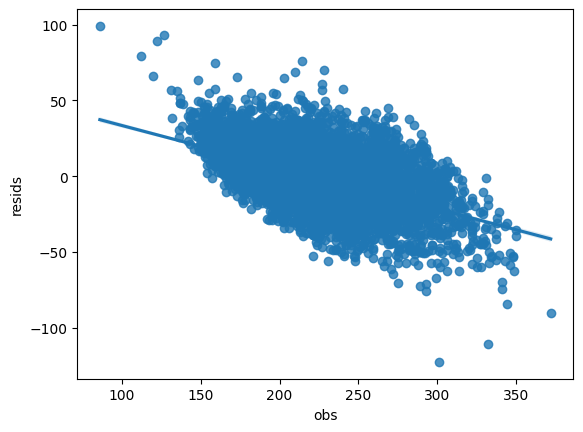

In [102]:
data = pd.DataFrame({
  'resids': 1.00827354*m1.predict(X_train_events)-1.835177853298461 - y_train_events,
  'obs': y_train_events
})
sns.regplot(data, x='obs', y='resids')

RMSE: 22.63
MAPE: 0.0685
MAE: 18.1762


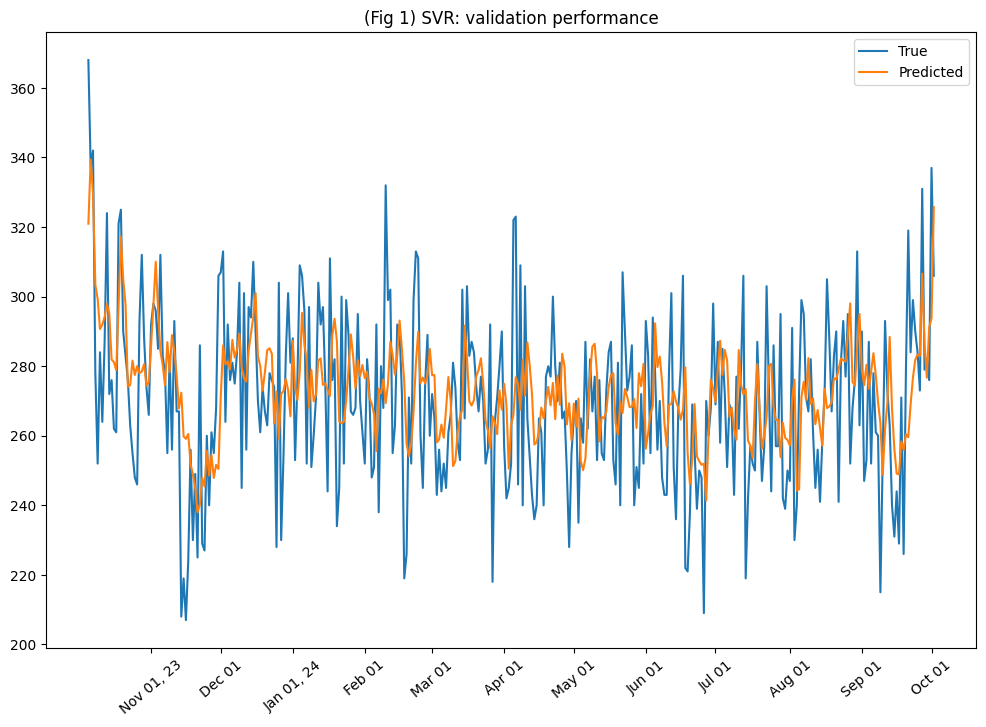

In [151]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
'feelslikemax', 'feelslikemin', 'windspeed'
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', StandardScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')

model = make_pipeline(transformer,
                    GridSearchCV(SVR(),
                                 # These parameters are the ones chosen after
                                 # much more turning previously
                                 param_grid={
                                     'C': [200, 300, 500, ],
                                     'epsilon': [1e-07, 1e-08],
                                     'gamma': [0.001]
                                 },
                                 scoring='neg_root_mean_squared_error',
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train_events, y_train_events)
validation_metrics(y_valid_events, model.predict(X_valid_events), PlotArgs('1', 'SVR'))

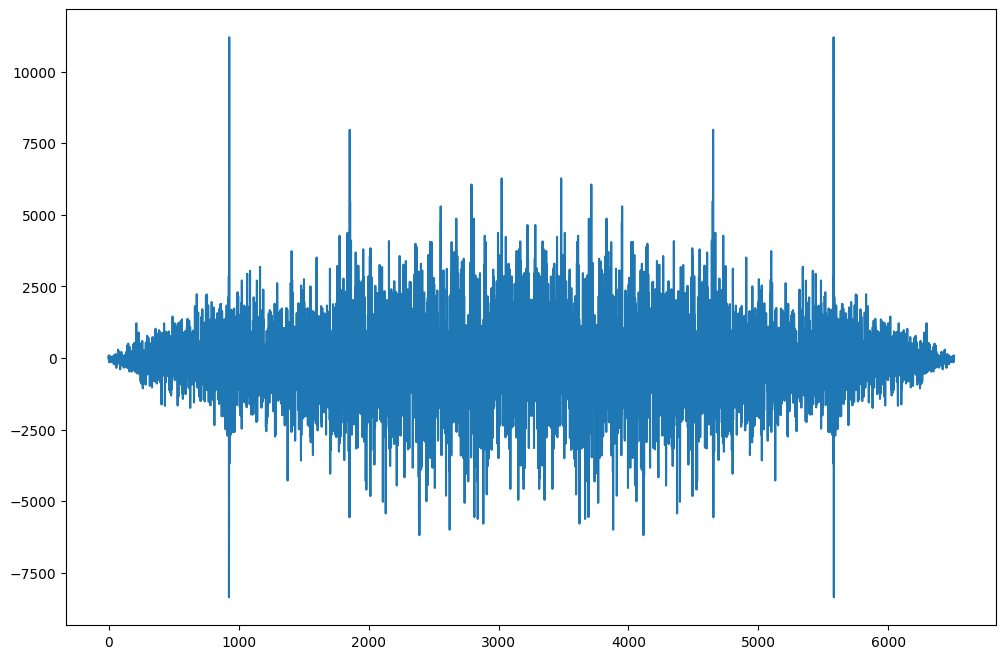

In [165]:
import scipy.fftpack

# Number of samplepoints

# sample spacing
T = 1.0
y = train.calls.diff().iloc[1:].tolist()
N = len(y)
x = list(range(len(y)))
yf = scipy.fftpack.fft(y)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)

fig, ax = plt.subplots()
ax.plot(yf)
#ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.show()

In [161]:
len(xf) 

300

In [164]:
y

440    -107.0
441      39.0
442      33.0
443     -28.0
444      14.0
        ...  
6941    -11.0
6942    -33.0
6943      8.0
6944     14.0
6945     27.0
Name: calls, Length: 6506, dtype: float64

Top 15 features:
                              feature  coefficient
135        numerical__remainder__lag1     0.286195
15         numerical__poly__tempmax^2     0.200713
217              remainder__new_years     0.193959
142       numerical__remainder__lag14     0.189944
141        numerical__remainder__lag7     0.147881
143       numerical__remainder__lag21     0.140441
136        numerical__remainder__lag2     0.132156
218                  remainder__pride     0.107585
140        numerical__remainder__lag6     0.103540
137        numerical__remainder__lag3     0.073249
216           remainder__thanksgiving    -0.059836
139        numerical__remainder__lag5     0.057000
163  cyclic_dayofweek__dayofweek_sp_6     0.049919
213           cyclic_week__week_sp_49     0.040641
146          cyclic_month__month_sp_1     0.028419
Used 41/219 features
RMSE: 0.08782
MAPE: 0.0124
MAE: 0.0695
Used 14 features to represent week of year
Used 8 features to represent month
Used 4 features to represent 

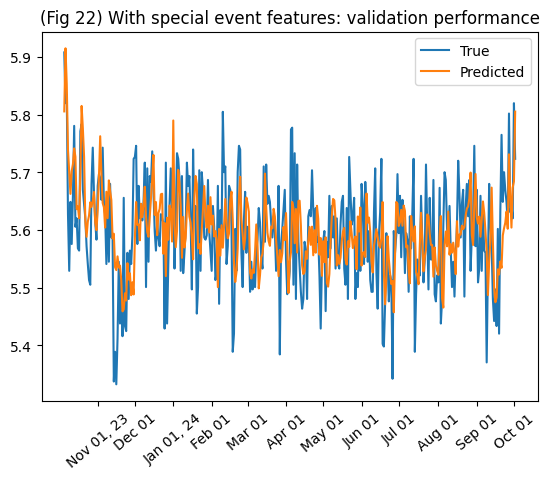

In [41]:
special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train_events, np.log(y_train_events))
eval_lasso(model, X_valid_events, np.log(y_valid_events), PlotArgs('22', 'With special event features'), transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

print(f'Used {len([feat for feat in used_feats if "week_sp" in feat])} features to represent week of year')
print(f'Used {len([feat for feat in used_feats if "month_sp" in feat])} features to represent month')
print(f'Used {len([feat for feat in used_feats if "dayofweek_sp" in feat])} features to represent day of week')
print(f'Used {len([feat for feat in used_feats if "numerical__poly" in feat])} weather features')

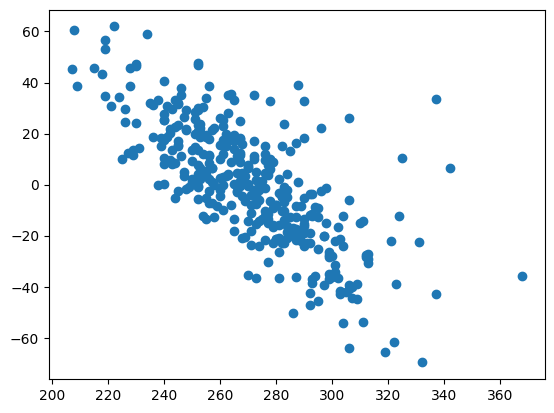

In [46]:
preds = np.exp(model.predict(X_valid_events))
resids = preds - y_valid_events
plt.scatter(y_valid_events, resids)

In [9]:
# Perform the rolling forecast
sarima_preds = []
for step in range(len(valid.calls)):
    # Get 1-step-ahead forecast from the end of the current predictions
    forecast_val = arima_mod_res.get_forecast(steps=1).predicted_mean.iloc[0]
    sarima_preds.append(forecast_val)

    # Update the model with the new observation
    arima_mod_res = arima_mod_res.append(endog=[valid.calls.iloc[step]])

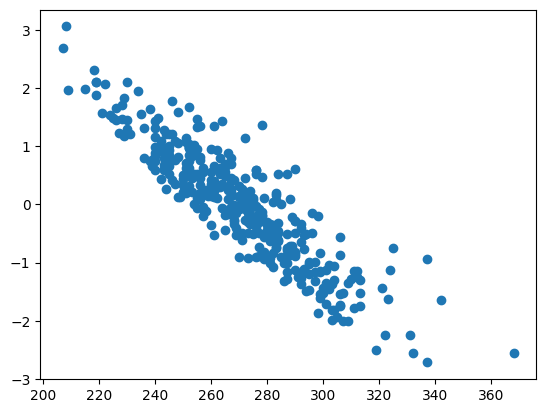

In [12]:
resids = sarima_preds - valid.calls
std_resids = (resids - resids.mean()) / resids.std()
plt.scatter(valid.calls, std_resids)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          1.,   1.,   0.,   1.,   1.,   1.,   6.,   2.,   8.,   6.,  11.,
         17.,  35.,  39.,  46.,  45.,  67.,  51., 100., 101., 112., 157.,
        145., 160., 117., 201., 205., 206., 194., 237., 202., 152., 170.,
        226., 203., 206., 198., 223., 118., 162., 159., 157., 161., 129.,
        138., 128.,  80., 135., 108., 119.,  92., 106.,  94.,  50.,  81.,
         70.,  56.,  73.,  53.,  48.,  36.,  39.,  37.,  34.,  35.,  26.,
         17.,  10.,  18.,  15.,   6.,  11.,   6.,  10.,   5.,   7.,   4.,
          4.,   4.,   4.,   3.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ 86.  ,  88.86,  91.72,  94.58,  97.44, 100.3 , 103.16, 106.02,
        108.88, 111.74, 114.6 , 117.46, 120.32, 123.18, 126.04, 128.9 ,
        131.76, 134.62, 137.48, 140.34, 143.2 , 146.06, 148.92, 151.78,
        154.64, 157.5 , 160.36, 163.22, 166.08, 168.94, 171.8 , 174.66,
        177.52, 180.38, 183.24

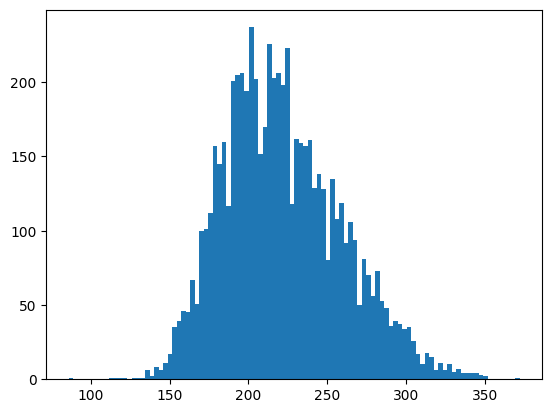

In [18]:
import numpy as np
plt.hist(train.calls, bins=100)

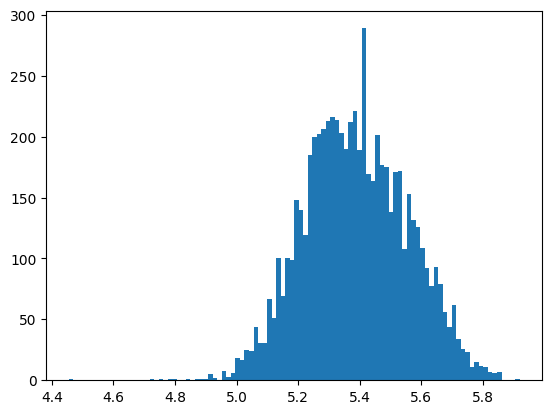

In [ ]:
import numpy as np
plt.hist(np.log(train.calls), bins=100);

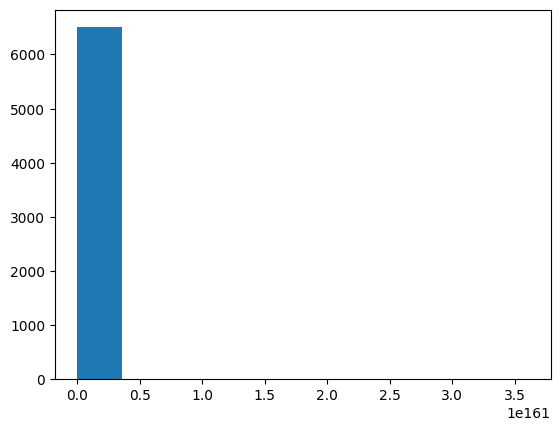

In [20]:
import numpy as np
plt.hist(np.exp(train.calls));

In [589]:
contained = []
for i in range(len(X_valid_events)):
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = poisson.interval(0.99, mu)
  obs = y_valid_events.iloc[i]
  contained.append(obs >= pi[0] and obs <= pi[1])
np.mean(contained)

np.float64(0.9397260273972603)

0.7890410958904109
54.07397260273972
0.7479452054794521
54.07123287671233


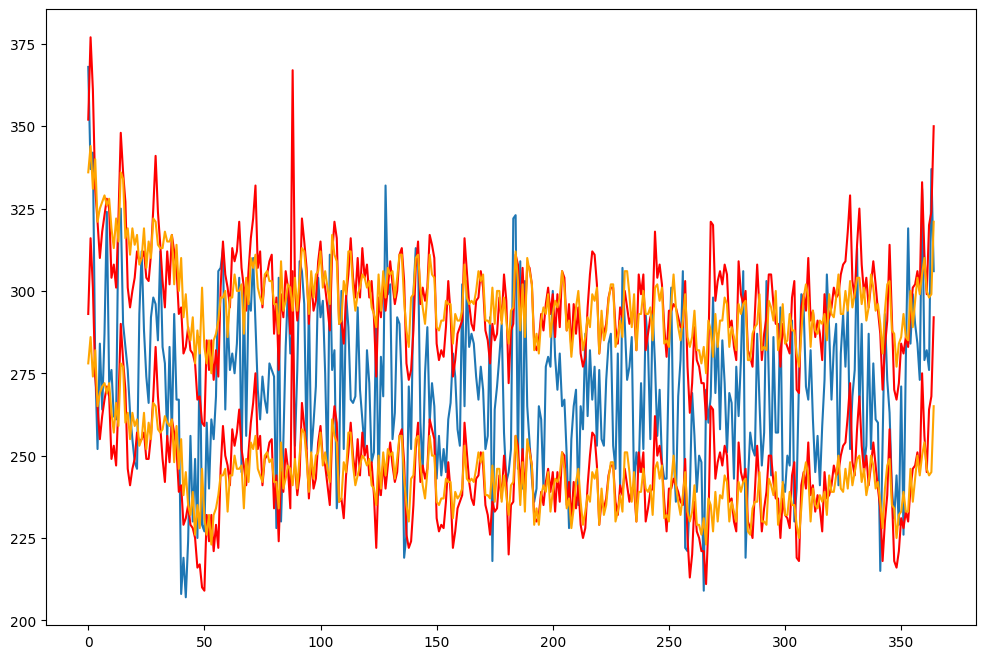

In [601]:
n = len(X_valid_events)
upper = np.zeros(n)
lower = np.zeros(n)
lr_contain = np.zeros(n)
upper_arima = np.zeros(n)
lower_arima = np.zeros(n)
arima_contain = np.zeros(n)
for i in range(len(X_valid_events)):
  obs = y_valid_events.iloc[i]
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = poisson.interval(0.90, mu)
  upper[i] = pi[1]
  lower[i] = pi[0]
  lr_contain[i] = (pi[0] <= obs <= pi[1])

  pi = poisson.interval(0.90, sarima_preds[i])
  upper_arima[i] = pi[1]
  lower_arima[i] = pi[0]
  arima_contain[i] = (pi[0] <= obs <= pi[1])

print(lr_contain.mean())
print((upper - lower).mean())
print(arima_contain.mean())
print((upper_arima - lower_arima).mean())
plt.subplots(figsize=(12,8))
plt.plot(y_valid_events)
plt.plot(upper, color='r')
plt.plot(lower, color='r')
plt.plot(upper_arima, color='orange')
plt.plot(lower_arima, color='orange')

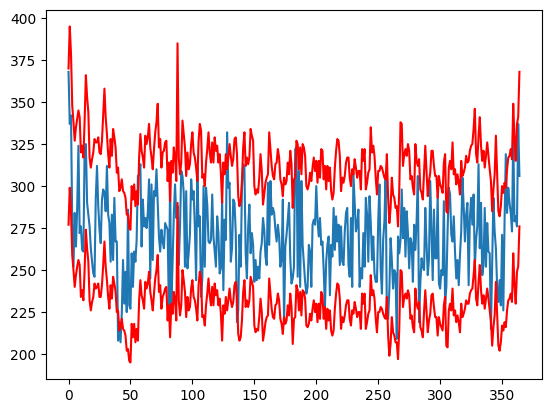

In [569]:
contained = []
for i in range(len(X_valid_events)):
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = (poisson.ppf(0.025, mu), poisson.ppf(0.975, mu))
  obs = y_valid_events.iloc[i]
  contained.append(obs >= pi[0] and obs <= pi[1])
np.mean(contained)

np.float64(0.8383561643835616)

RMSE: 23.85
MAPE: 0.0703
MAE: 18.8061


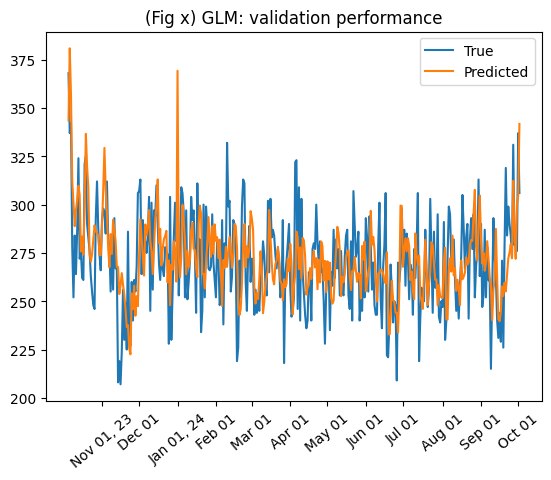

In [615]:
from sklearn.linear_model import PoissonRegressor


special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer,
                      GridSearchCV(PoissonRegressor(),
                                 # These parameters are the ones chosen after
                                 # much more turning previously
                                 param_grid={
                                     'alpha': np.linspace(0, 10, 1)
                                 },
                                 cv=ts_cv,
                                 refit=True))
model.fit(X_train_events, y_train_events)
validation_metrics(y_valid_events, model.predict(X_valid_events), PlotArgs('x', 'GLM'))

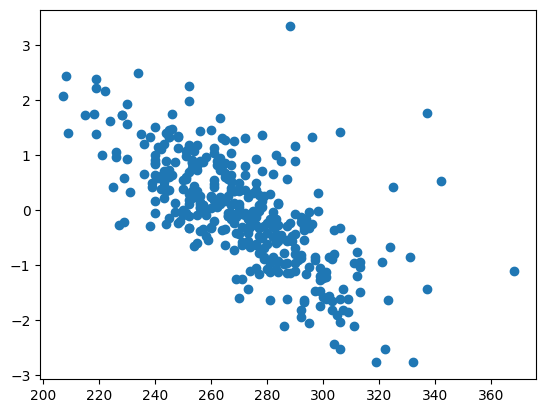

In [616]:
resids = model.predict(X_valid_events) - y_valid_events
std_resids = (resids - resids.mean()) / resids.std()
plt.scatter(x=y_valid_events, y=std_resids)

<Axes: ylabel='Frequency'>

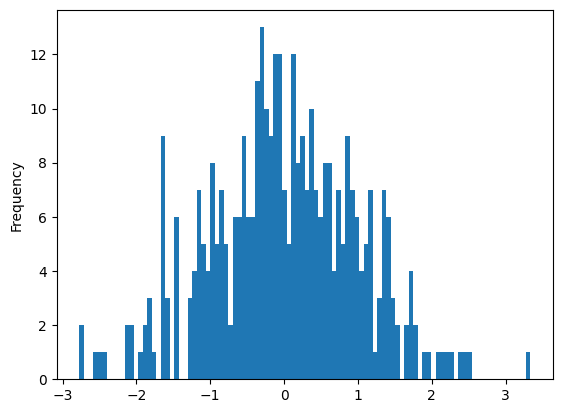

In [635]:
std_resids.plot.hist(bins=100)

<Axes: ylabel='Frequency'>

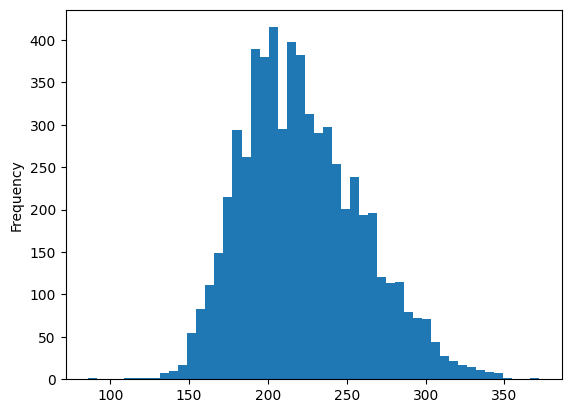

In [636]:
y_train_events.plot.hist(bins=50)

In [630]:
# Calculate Deviance: Sum of (2 * (y * log(y / y_pred) - (y - y_pred))) for non-zero y
y_pred = model.predict(X_valid_events)
y = y_valid_events.tolist()
deviance = 2 * np.sum(y * np.log(y / y_pred) - (y - y_pred))

# Calculate Degrees of Freedom
# Degrees of freedom = Number of observations - Number of parameters estimated
degrees_of_freedom = len(y) - (len(transformer.get_feature_names_out()) + 1)  # +1 for intercept

# Calculate Overdispersion Statistic
overdispersion_statistic = deviance / degrees_of_freedom
overdispersion_statistic

np.float64(5.25325792241816)

In [617]:
contained = []
for i in range(len(X_valid_events)):
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = poisson.interval(0.99, mu)
  obs = y_valid_events.iloc[i]
  contained.append(obs >= pi[0] and obs <= pi[1])
np.mean(contained)

np.float64(0.9315068493150684)

RMSE: 22.65
MAPE: 0.0672
MAE: 17.9879


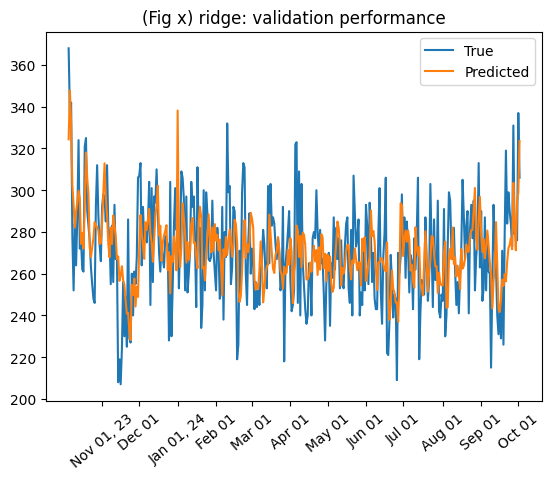

In [610]:
from sklearn.linear_model import RidgeCV

special_day_vars = ['thanksgiving', 'new_years', 'pride']
cat_cols = ['dayofweek', 'month', 'week']
num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'windspeed', 'sealevelpressure', 'cloudcover',
    'visibility',
]
num_cols = ['lag1', 'lag2', 'lag3', 'lag4',
    'lag5', 'lag6', 'lag7', 'lag14', 'lag21', 'year'] + num_weather_feats

feats = num_cols + cat_cols + special_day_vars

train_events1 = train_events_final[train_events_final.year != 2020]
X_train_events, y_train_events = train_events1[feats], train_events1.calls
X_valid_events, y_valid_events = valid_events[feats], valid_events.calls

numerical_transformer = Pipeline(steps=[
    ('poly_selector', ColumnTransformer(
        transformers=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False), num_weather_feats)
        ], remainder='passthrough')),
    ('scaler', MinMaxScaler())
])

transformer = ColumnTransformer([
        ('numerical', numerical_transformer, num_cols),
        ("cyclic_month", periodic_spline_transformer(12), ["month"]),
        ("cyclic_dayofweek", periodic_spline_transformer(7), ["dayofweek"]),
        ("cyclic_week", periodic_spline_transformer(52), ["week"]),
    ], remainder='passthrough')


model = make_pipeline(transformer, RidgeCV(cv=ts_cv))
model.fit(X_train_events, y_train_events)
validation_metrics(y_valid_events, model.predict(X_valid_events), PlotArgs('x', 'ridge'))

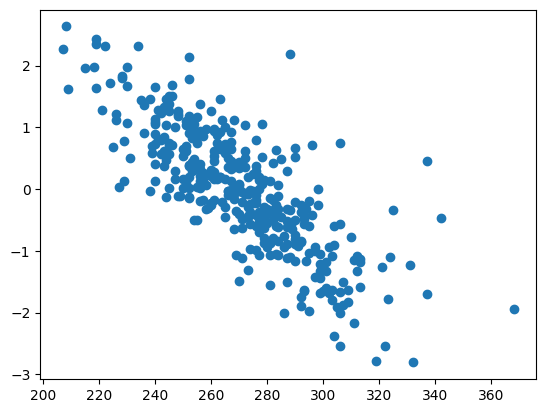

In [614]:
resids = model.predict(X_valid_events) - y_valid_events
std_resids = (resids - resids.mean()) / resids.std()
plt.scatter(x=y_valid_events, y=std_resids)

0.9397260273972603
84.67945205479452
0.9315068493150684
84.63013698630137


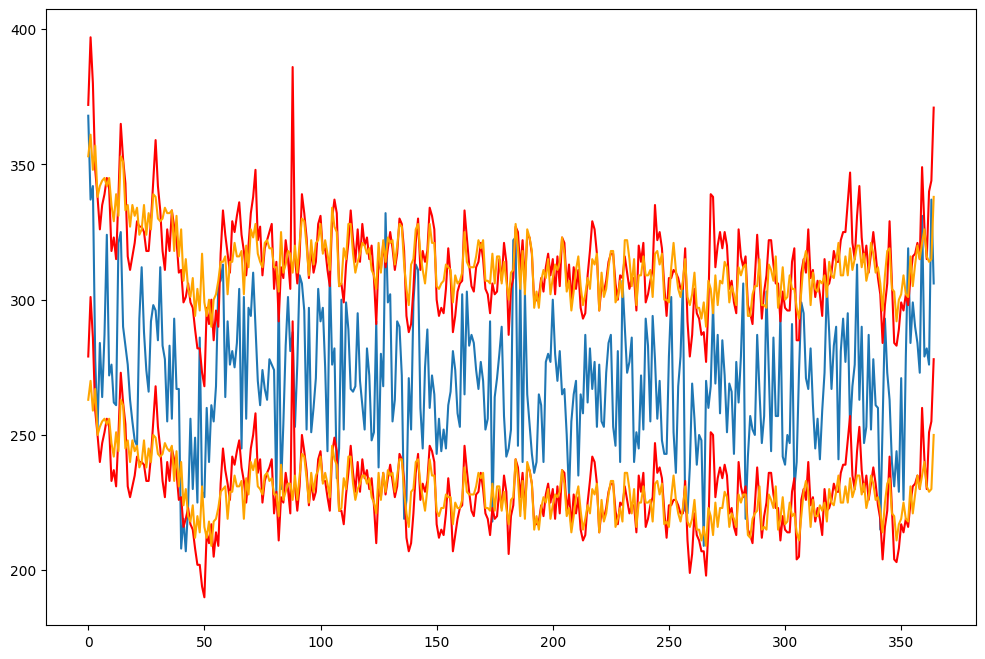

In [607]:
n = len(X_valid_events)
upper = np.zeros(n)
lower = np.zeros(n)
lr_contain = np.zeros(n)
upper_arima = np.zeros(n)
lower_arima = np.zeros(n)
arima_contain = np.zeros(n)
for i in range(len(X_valid_events)):
  obs = y_valid_events.iloc[i]
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = poisson.interval(0.99, mu)
  upper[i] = pi[1]
  lower[i] = pi[0]
  lr_contain[i] = (pi[0] <= obs <= pi[1])

  pi = poisson.interval(0.99, sarima_preds[i])
  upper_arima[i] = pi[1]
  lower_arima[i] = pi[0]
  arima_contain[i] = (pi[0] <= obs <= pi[1])

print(lr_contain.mean())
print((upper - lower).mean())
print(arima_contain.mean())
print((upper_arima - lower_arima).mean())
plt.subplots(figsize=(12,8))
plt.plot(y_valid_events)
plt.plot(upper, color='r')
plt.plot(lower, color='r')
plt.plot(upper_arima, color='orange')
plt.plot(lower_arima, color='orange')

In [ ]:
n = len(X_valid_events)
upper = np.zeros(n)
lower = np.zeros(n)
lr_contain = np.zeros(n)
upper_arima = np.zeros(n)
lower_arima = np.zeros(n)
arima_contain = np.zeros(n)
for i in range(len(X_valid_events)):
  obs = y_valid_events.iloc[i]
  mu = model.predict(X_valid_events.iloc[i:i+1])
  pi = poisson.interval(0.99, mu)
  upper[i] = pi[1]
  lower[i] = pi[0]
  lr_contain[i] = (pi[0] <= obs <= pi[1])

  pi = poisson.interval(0.99, sarima_preds[i])
  upper_arima[i] = pi[1]
  lower_arima[i] = pi[0]
  arima_contain[i] = (pi[0] <= obs <= pi[1])

print(lr_contain.mean())
print((upper - lower).mean())
print(arima_contain.mean())
print((upper_arima - lower_arima).mean())
plt.subplots(figsize=(12,8))
plt.plot(y_valid_events)
plt.plot(upper, color='r')
plt.plot(lower, color='r')
plt.plot(upper_arima, color='orange')
plt.plot(lower_arima, color='orange')

TODO:
- comment on last model
- evaluate model over baseline. where does it improve/where is it kinda the same?

## References
[1] Channouf N, L'Ecuyer P, Ingolfsson A, Avramidis AN. The application of forecasting techniques to modeling emergency medical system calls in Calgary, Alberta. Health Care Manag Sci. 2007 Feb;10(1):25-45. doi: 10.1007/s10729-006-9006-3. PMID: 17323653.

[2] A. Haugsbø Hermansen and O. J. Mengshoel, "Forecasting Ambulance Demand using Machine Learning: A Case Study from Oslo, Norway," 2021 IEEE Symposium Series on Computational Intelligence (SSCI), Orlando, FL, USA, 2021, pp. 01-10, doi: 10.1109/SSCI50451.2021.9659837.

[3] R. Justin Martin, Reza Mousavi, Cem Saydam, "Predicting emergency medical service call demand: A modern spatiotemporal machine learning approach" Operations Research for Health Care, Volume 28, 2021, 100285, ISSN 2211-6923, https://doi.org/10.1016/j.orhc.2021.100285. (https://www.sciencedirect.com/science/article/pii/S2211692321000011)

[4] Wong, HT., Lai, PC. Weather factors in the short-term forecasting of daily ambulance calls. Int J Biometeorol 58, 669–678 (2014). https://doi.org/10.1007/s00484-013-0647-x